In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

PROCESSED_DIR = Path('../../data/processed/Ulta')
OUTPUT_DIR = Path('outputs/ulta_segmentation')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

K_RANGE = range(2, 11)

In [30]:
df = pd.read_csv(PROCESSED_DIR / 'ulta_segmentation.csv')
print(f'{len(df):,} products loaded')
df.head()

11,227 products loaded


,product_id,product_url,brand,product_name,category,price,rating,review_count,avg_rating,rating_std,...,review_count_normalized,rating_dispersion_over_time,top_topic_prevalence,helpfulness_rate,pct_verified_buyer,pct_verified_reviewer,pct_would_recommend,pct_has_disclosure,price_bucket,price_vs_category_median
0,pimprod2046204,https://www.ulta.com/p/lip-quench-hydrating-ba...,ULTA Beauty Collection,Lip Quench Hydrating Balm - Caramel Syrup,Lip Balms,10.0,4.6,218,4.637615,0.700137,...,0.725753,0.890347,0.587156,0.727273,0.201835,0.857798,0.944954,0.655963,10-20,0.625
1,pimprod2045216,https://www.ulta.com/p/eyeshadow-singles-pimpr...,ULTA Beauty Collection,Eyeshadow Singles - Summer In Paris,Eyeshadow,9.0,4.2,231,4.229437,1.306904,...,0.769231,0.852021,0.329004,0.825160,0.238095,0.238095,0.800866,0.000000,0-10,0.360
2,pimprod2046514,https://www.ulta.com/p/automatic-retractable-e...,ULTA Beauty Collection,Automatic Retractable Eyeliner - Metallic Teal,Eyeliner,9.5,4.1,237,4.004219,1.465704,...,0.789298,0.864942,0.206751,0.884319,0.523207,0.523207,0.734177,0.000000,0-10,0.475
3,pimprod2046716,https://www.ulta.com/p/cream-eye-shadow-stick-...,ULTA Beauty Collection,"Cream Eye Shadow Stick - Beige, Pls",Eyeshadow,10.5,4.2,209,4.119617,1.427763,...,0.695652,0.630375,0.248804,0.875000,0.425837,0.425837,0.789474,0.000000,10-20,0.420
4,pimprod2045990,https://www.ulta.com/p/gel-eyeliner-pencil-pim...,ULTA Beauty Collection,Gel Eyeliner Pencil - Mink,Eyeliner,10.5,4.2,239,4.020921,1.415543,...,0.795987,0.984711,0.225941,0.795217,0.640167,0.640167,0.736402,0.000000,10-20,0.525


In [31]:
core_features = [
    'avg_rating', 'rating_std',
    'pct_5_star', 'pct_4_star', 'pct_3_star', 'pct_2_star', 'pct_1_star',
    'avg_sentiment', 'pct_positive', 'pct_negative',
    'reviews_per_month', 'review_count_normalized',
    'rating_dispersion_over_time', 'top_topic_prevalence',
    'dominant_topic_mode', 'price', 'price_vs_category_median',
    'helpfulness_rate',
    # Ulta-specific
    'pct_verified_buyer', 'pct_verified_reviewer',
    'pct_would_recommend', 'pct_has_disclosure',
]

feature_names = [f for f in core_features if f in df.columns]
print(f'Selected {len(feature_names)} features')

X = df[feature_names].apply(pd.to_numeric, errors='coerce').fillna(0)
weights = np.clip(pd.to_numeric(df['review_count_normalized'], errors='coerce').fillna(0).values, 0.1, 1.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Feature matrix: {X_scaled.shape}')

Selected 22 features
Feature matrix: (11227, 22)


In [32]:
def plot_silhouette_detail(X_scaled, labels, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    sil_vals = silhouette_samples(X_scaled, labels)
    n_clusters = len(set(labels))
    y_lower = 10

    for i in range(n_clusters):
        cluster_sil = np.sort(sil_vals[labels == i])
        size = len(cluster_sil)
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10, fontweight='bold')
        y_lower = y_upper + 10

    avg_sil = sil_vals.mean()
    ax.axvline(avg_sil, color='red', linestyle='--', label=f'Avg: {avg_sil:.3f}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_title(title)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


profile_features = [
    'avg_rating', 'avg_sentiment', 'price', 'reviews_per_month',
    'pct_5_star', 'pct_1_star', 'pct_positive', 'pct_negative',
    'rating_std', 'price_vs_category_median', 'review_count_normalized',
    'top_topic_prevalence', 'rating_dispersion_over_time',
]
profile_features = [f for f in profile_features if f in df.columns]


def profile_clusters(df, col):
    profiles = df.groupby(col)[profile_features].mean()
    profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(14, max(6, len(profiles) * 1.5)))
    sns.heatmap(profiles_norm.T, annot=profiles.T.round(3), fmt='', cmap='YlOrRd',
                xticklabels=[f'Cluster {i}' for i in profiles.index],
                yticklabels=profiles.columns, ax=ax, linewidths=0.5)
    ax.set_title(f'Cluster Profiles — {col}', fontsize=14)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'profile_{col}.png', dpi=150)
    plt.show()

    for cluster_id in sorted(df[col].unique()):
        c = df[df[col] == cluster_id]
        print(f'\n  Cluster {cluster_id} ({len(c):,} products, {len(c)/len(df)*100:.1f}%)')
        print(f'  Top categories: {c["category"].value_counts().head(5).to_dict()}')
        print(f'  Top brands: {c["brand"].value_counts().head(5).to_dict()}')
        print(f'  Price: ${c["price"].min():.0f}-${c["price"].max():.0f} (median ${c["price"].median():.0f})')
        print(f'  Avg rating: {c["avg_rating"].mean():.2f}  |  Avg sentiment: {c["avg_sentiment"].mean():.3f}')
        print(f'  Reviews/month: {c["reviews_per_month"].mean():.1f}  |  Rating std: {c["rating_std"].mean():.3f}')

# Model 1: K-means (Unweighted)

  k=2: WCSS=205,962  silhouette=0.1951
  k=3: WCSS=190,587  silhouette=0.1304
  k=4: WCSS=177,668  silhouette=0.1346
  k=5: WCSS=168,957  silhouette=0.1266
  k=6: WCSS=162,137  silhouette=0.1182
  k=7: WCSS=155,286  silhouette=0.1175
  k=8: WCSS=150,340  silhouette=0.1158
  k=9: WCSS=143,900  silhouette=0.1201
  k=10: WCSS=139,565  silhouette=0.1181


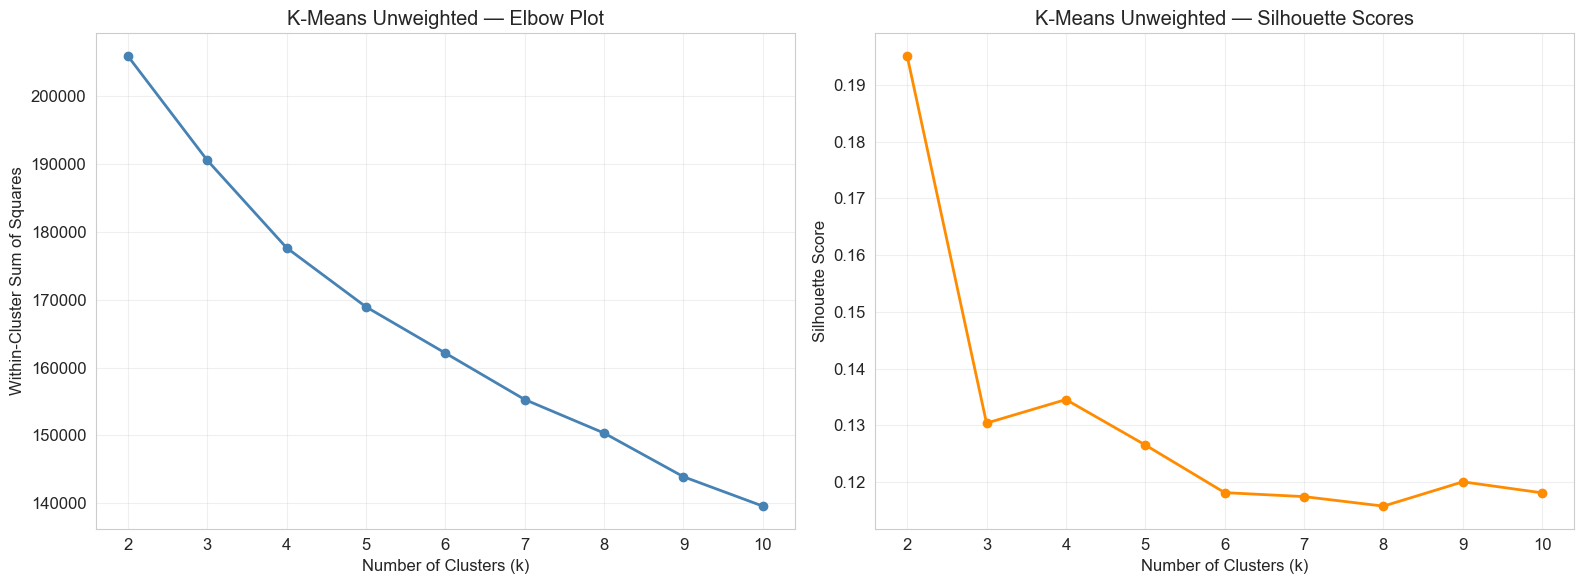

In [33]:
km_uw_inertias, km_uw_silhouettes, km_uw_models = [], [], {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    km_uw_inertias.append(km.inertia_)
    km_uw_silhouettes.append(sil)
    km_uw_models[k] = km
    print(f'  k={k}: WCSS={km.inertia_:,.0f}  silhouette={sil:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(list(K_RANGE), km_uw_inertias, 'o-', linewidth=2, color='steelblue')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares')
ax1.set_title('K-Means Unweighted — Elbow Plot')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), km_uw_silhouettes, 'o-', linewidth=2, color='darkorange')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('K-Means Unweighted — Silhouette Scores')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'km_uw_elbow_silhouette.png', dpi=150)
plt.show()

In [34]:
KM_UW_K = 3

K-Means Unweighted (k=3): silhouette=0.1304


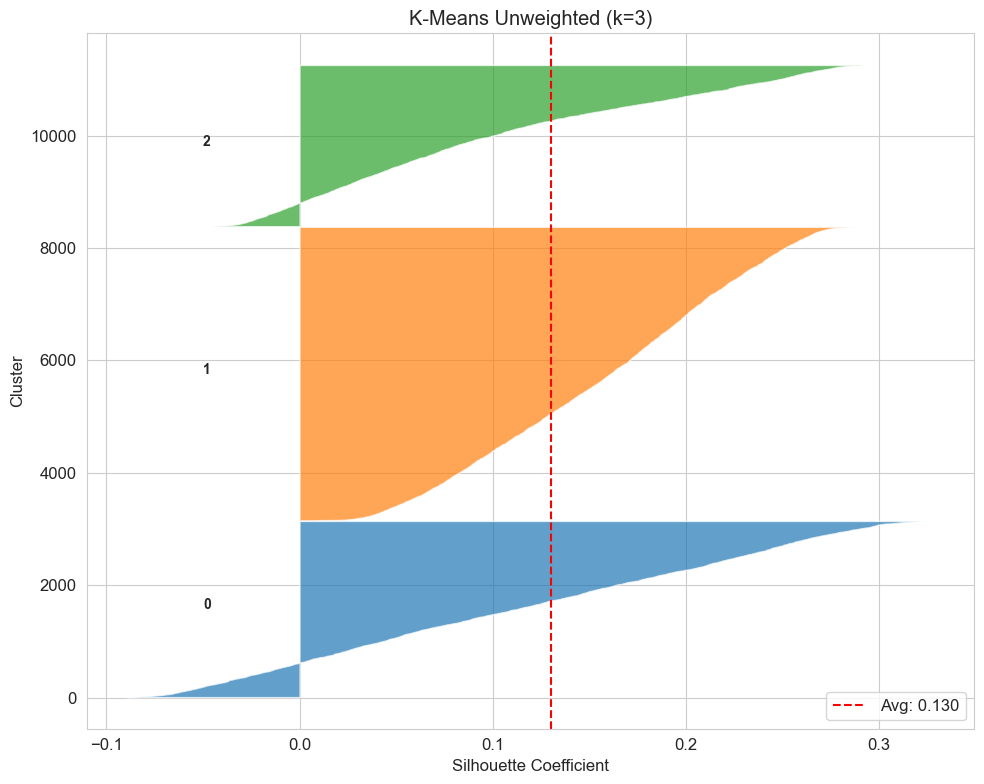

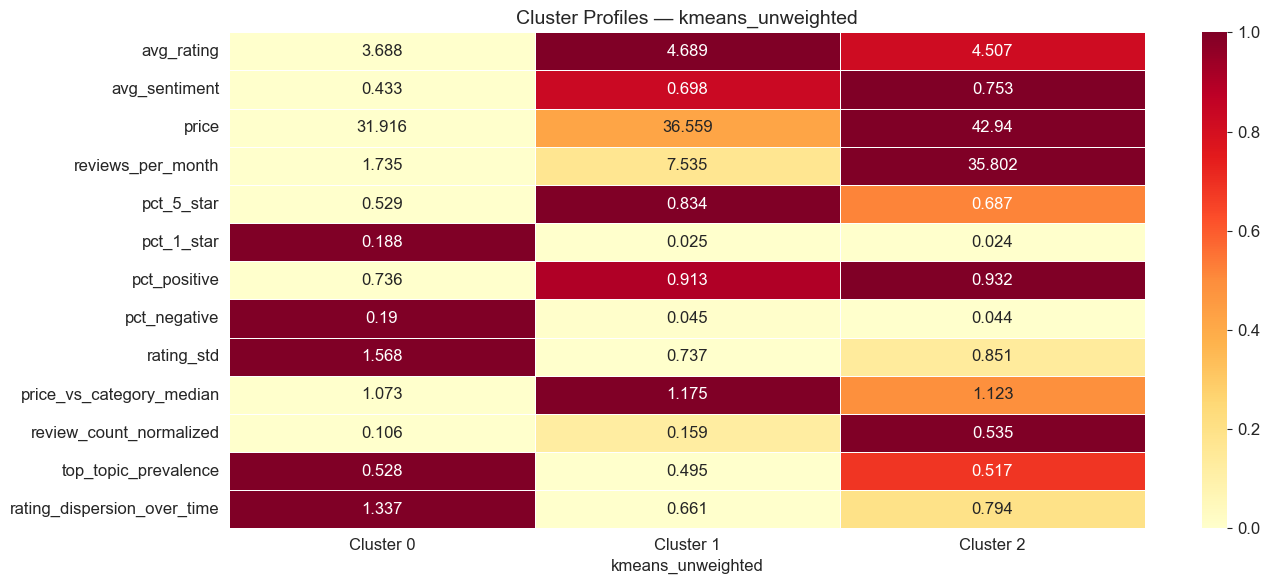


  Cluster 0 (3,135 products, 27.9%)
  Top categories: {'Face Serums': 125, 'Travel Size Hair Care': 108, 'Shampoo': 98, 'Face Moisturizer': 85, 'Sunscreen': 77}
  Top brands: {'J.Cat Beauty': 29, 'Glamnetic': 28, 'The Ordinary': 28, 'Peach Slices': 27, 'Red Carpet Manicure': 27}
  Price: $2-$550 (median $23)
  Avg rating: 3.69  |  Avg sentiment: 0.433
  Reviews/month: 1.7  |  Rating std: 1.568

  Cluster 1 (5,223 products, 46.5%)
  Top categories: {'Face Serums': 222, 'Perfume': 204, 'Face Moisturizer': 185, 'Travel Size Hair Care': 149, 'Face Wash': 135}
  Top brands: {'RMS Beauty': 46, 'Moroccanoil': 45, 'amika': 42, 'jane iredale': 39, 'Snif': 39}
  Price: $2-$495 (median $27)
  Avg rating: 4.69  |  Avg sentiment: 0.698
  Reviews/month: 7.5  |  Rating std: 0.737

  Cluster 2 (2,869 products, 25.6%)
  Top categories: {'Perfume': 139, 'Face Moisturizer': 123, 'Cologne': 115, 'Face Serums': 110, 'Travel Size Hair Care': 102}
  Top brands: {'KRISTIN ESS HAIR': 42, 'NUDESTIX': 39, 'MAC'

In [35]:
df['kmeans_unweighted'] = km_uw_models[KM_UW_K].labels_
sil = silhouette_score(X_scaled, df['kmeans_unweighted'].values)
print(f'K-Means Unweighted (k={KM_UW_K}): silhouette={sil:.4f}')

plot_silhouette_detail(X_scaled, df['kmeans_unweighted'].values,
                       f'K-Means Unweighted (k={KM_UW_K})')

profile_clusters(df, 'kmeans_unweighted')

K-Means Unweighted (k=3): silhouette=0.1304



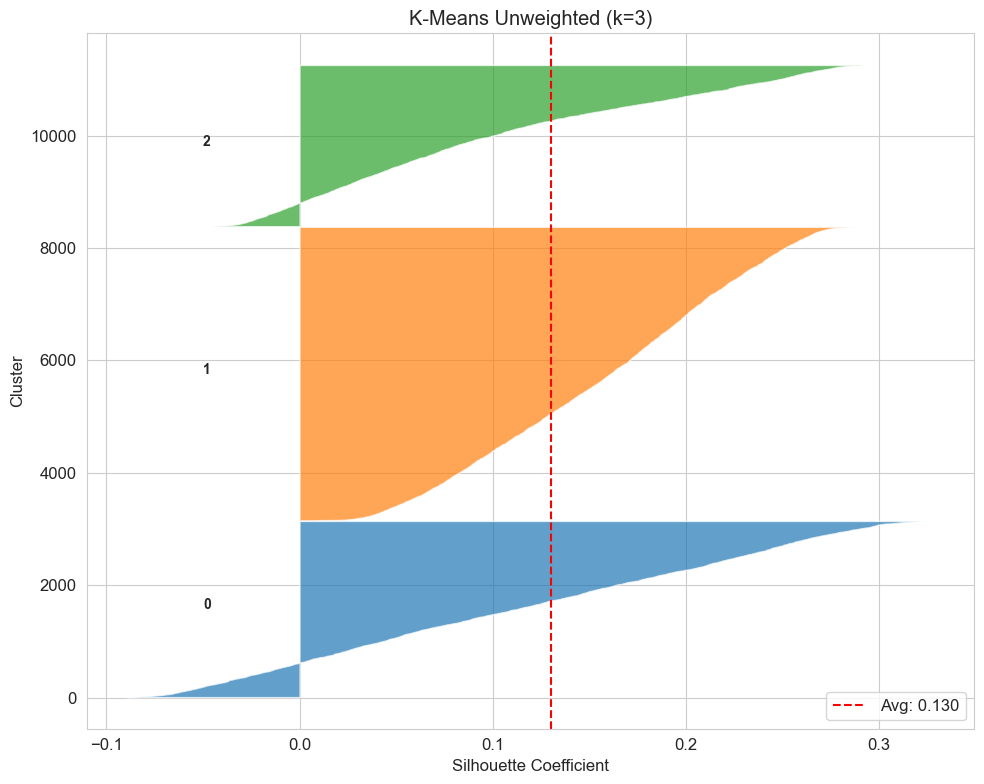


CLUSTER 0 — 3,135 products (27.9%)

  --- Product Info ---
  Top categories:  {'Face Serums': 125, 'Travel Size Hair Care': 108, 'Shampoo': 98, 'Face Moisturizer': 85, 'Sunscreen': 77}
  Top brands:      {'J.Cat Beauty': 29, 'Glamnetic': 28, 'The Ordinary': 28, 'Peach Slices': 27, 'Red Carpet Manicure': 27}
  Price range:     $1.50 - $549.99
  Price median:    $23.00
  Price mean:      $31.92
  Price vs cat median: 1.073
  Price bucket dist:
    10-20: 946 (30.2%)
    20-30: 806 (25.7%)
    30-40: 423 (13.5%)
    0-10: 354 (11.3%)
    40-50: 204 (6.5%)

  --- Ratings ---
  Avg rating:      3.688
  Rating std:      1.568
  Rating dispersion over time: 1.337
  Pct 5-star:      0.529 (52.9%)
  Pct 4-star:      0.101 (10.1%)
  Pct 3-star:      0.087 (8.7%)
  Pct 2-star:      0.095 (9.5%)
  Pct 1-star:      0.188 (18.8%)

  --- Sentiment ---
  Avg sentiment:   0.433
  Pct positive:    0.736 (73.6%)
  Pct negative:    0.190 (19.0%)
  Pct neutral:     0.074 (7.4%)

  --- Review Velocity & En

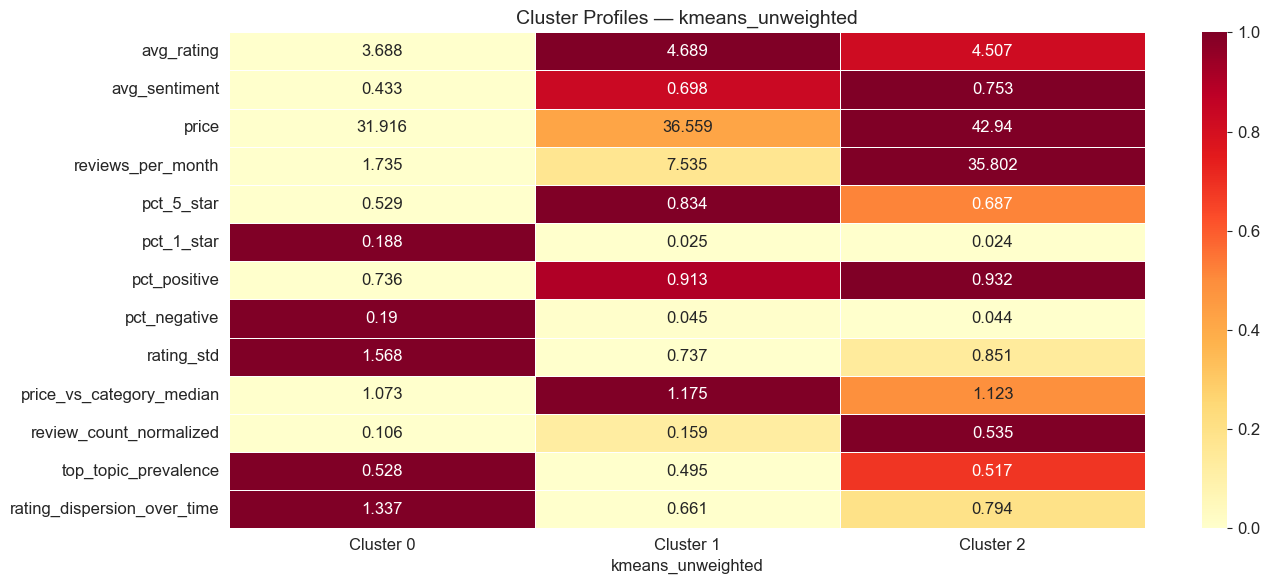


  Cluster 0 (3,135 products, 27.9%)
  Top categories: {'Face Serums': 125, 'Travel Size Hair Care': 108, 'Shampoo': 98, 'Face Moisturizer': 85, 'Sunscreen': 77}
  Top brands: {'J.Cat Beauty': 29, 'Glamnetic': 28, 'The Ordinary': 28, 'Peach Slices': 27, 'Red Carpet Manicure': 27}
  Price: $2-$550 (median $23)
  Avg rating: 3.69  |  Avg sentiment: 0.433
  Reviews/month: 1.7  |  Rating std: 1.568

  Cluster 1 (5,223 products, 46.5%)
  Top categories: {'Face Serums': 222, 'Perfume': 204, 'Face Moisturizer': 185, 'Travel Size Hair Care': 149, 'Face Wash': 135}
  Top brands: {'RMS Beauty': 46, 'Moroccanoil': 45, 'amika': 42, 'jane iredale': 39, 'Snif': 39}
  Price: $2-$495 (median $27)
  Avg rating: 4.69  |  Avg sentiment: 0.698
  Reviews/month: 7.5  |  Rating std: 0.737

  Cluster 2 (2,869 products, 25.6%)
  Top categories: {'Perfume': 139, 'Face Moisturizer': 123, 'Cologne': 115, 'Face Serums': 110, 'Travel Size Hair Care': 102}
  Top brands: {'KRISTIN ESS HAIR': 42, 'NUDESTIX': 39, 'MAC'

In [36]:
KM_UW_K = 3
df['kmeans_unweighted'] = km_uw_models[KM_UW_K].labels_

sil = silhouette_score(X_scaled, df['kmeans_unweighted'].values)
print(f'K-Means Unweighted (k={KM_UW_K}): silhouette={sil:.4f}\n')

plot_silhouette_detail(X_scaled, df['kmeans_unweighted'].values,
                       f'K-Means Unweighted (k={KM_UW_K})')

for cluster_id in sorted(df['kmeans_unweighted'].unique()):
    c = df[df['kmeans_unweighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Helpfulness rate:          {c["helpfulness_rate"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    # Ulta-specific: Verified & Recommendation signals
    print(f'\n  --- Verified Buyer & Recommendation ---')
    print(f'  Pct verified buyer:        {c["pct_verified_buyer"].mean():.3f} ({c["pct_verified_buyer"].mean()*100:.1f}%)')
    print(f'  Pct verified reviewer:     {c["pct_verified_reviewer"].mean():.3f} ({c["pct_verified_reviewer"].mean()*100:.1f}%)')
    print(f'  Pct would recommend:       {c["pct_would_recommend"].mean():.3f} ({c["pct_would_recommend"].mean()*100:.1f}%)')
    print(f'  Pct has disclosure:        {c["pct_has_disclosure"].mean():.3f} ({c["pct_has_disclosure"].mean()*100:.1f}%)')

profile_clusters(df, 'kmeans_unweighted')

In [37]:
for cluster_id in sorted(df['kmeans_unweighted'].unique()):
    c = df[df['kmeans_unweighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')


CLUSTER 0 — 3,135 products, 29 unique brands
  J.Cat Beauty                                   29 (0.9%)
  Glamnetic                                      28 (0.9%)
  The Ordinary                                   28 (0.9%)
  Peach Slices                                   27 (0.9%)
  Red Carpet Manicure                            27 (0.9%)
  Tarte                                          27 (0.9%)
  BaBylissPRO                                    26 (0.8%)
  Naturium                                       26 (0.8%)
  Verb                                           26 (0.8%)
  Joico                                          25 (0.8%)
  CoverGirl                                      24 (0.8%)
  Wet n Wild                                     24 (0.8%)
  Essence                                        23 (0.7%)
  Scünci                                         23 (0.7%)
  PAT McGRATH LABS                               22 (0.7%)
  Biolage                                        22 (0.7%)
  Briogeo 

## Cluster 0 — "Polarizing Underperformers" (3,135 products · 27.9%)
The weakest segment on Ulta. Average rating of 3.69 with the highest variance across all clusters (1.57 std), meaning customers land at the extremes — 52.9% 5-star but 18.8% 1-star. Sentiment is the lowest at 0.433, with 19% negative reviews. Velocity is nearly stagnant at 1.7 reviews/month, and review_count_normalized is just 0.106, indicating these products sit on the shelf without generating organic conversation.The brand composition tells the story: J.Cat Beauty, Glamnetic, Peach Slices, Red Carpet Manicure — budget-tier or niche brands without strong marketing engines. Categories skew functional (shampoo, sunscreen, travel sizes) rather than aspirational. Price is the lowest (median $23), and only 40.9% of reviewers would recommend — the lowest by far. Topic 8 dominates at 40.8%, suggesting a concentrated complaint pattern. The 2.8% disclosure rate and 19.5% verified buyer rate indicate these are genuine, unmediated consumer reactions — and the reactions are mixed at best.Marketing implication: these products need intervention. The high variance suggests fixable product-market fit issues (some customers love them, many don't) rather than universal rejection. Targeted reformulation or repositioning could salvage the segment.
## Cluster 1 — "Quiet Loyalists" (5,223 products · 46.5%)
The largest segment and the quality backbone of Ulta's assortment. Rating of 4.69 is the highest across clusters, with remarkably tight consistency (0.74 std) — customers overwhelmingly agree these products work. 83.4% 5-star, only 2.5% 1-star. Sentiment of 0.698 with 91.3% positive reviews. These products perform and customers know it.Velocity is moderate at 7.5 reviews/month — enough to signal healthy engagement without artificial inflation. The verified buyer rate (20%) and verified reviewer rate (11.3%) are both organic: these reviews come from real purchasers, not sampling programs. Disclosure rate is just 2.1%. The 57.9% recommendation rate is solid for a genuine, unmediated pool.Brands here are premium indie and prestige: RMS Beauty, Moroccanoil, amika, jane iredale, Snif. Categories include perfume, face serums, face wash — products where ingredient quality and formulation drive loyalty. Price is mid-range (median $27) with a slight premium vs category median (1.175×).Topic distribution is the most balanced across all clusters — no single topic exceeds 20.8% — suggesting satisfaction is broad-based rather than driven by one attribute. These products don't polarize because they deliver consistently.Marketing implication: amplification opportunity. These products have proven product-market fit but lack the velocity to maximize their potential. Strategic sampling, influencer partnerships, or featured placement could accelerate growth without risking the authentic sentiment they've built.
## Cluster 2 — "Seeded High-Traffic" (2,869 products · 25.6%)
The Ulta-specific finding with no Sephora parallel. Highest velocity at 35.8 reviews/month and highest sentiment at 0.753 with 93.2% positive — but the provenance of that sentiment is suspect. Only 9.0% are verified buyers, while 57.3% are verified reviewers and 47.4% carry disclosure codes. Nearly half the review volume comes from incentivized or sampling programs.The brand composition confirms this: KRISTIN ESS HAIR, NUDESTIX, MAC, Redken, Dior — established brands with the marketing budgets and retail relationships to run large-scale sampling programs through Ulta's infrastructure. Price is the highest (median $26, mean $43), and 79.9% would recommend, but that metric is inflated by participants who received free product.Rating of 4.51 with 0.85 std is good but notably lower than Cluster 1's 4.69 despite higher sentiment — a subtle mismatch suggesting that seeded reviews skew more effusively positive in text while star ratings stay slightly more honest. Review count is massive (mean 160.9, median 174) dwarfing both other clusters.The key question this cluster raises: does the high sentiment survive when filtered to verified buyers only? If Cluster 2 brands show significant sentiment drops under verified-only filtering — which the brand health dashboard's toggle can test — you've identified systematic review inflation on Ulta. This is a publishable finding about how retailer-specific review ecosystems shape brand perception.

# Model 2: K-means (Weighted)

In [38]:
feature_weights = {}
for f in feature_names:
    if f in ('reviews_per_month', 'review_count_normalized'):
        feature_weights[f] = 2.0  # review velocity
    elif f in ('avg_sentiment', 'pct_positive', 'pct_negative', 'pct_neutral'):
        feature_weights[f] = 2.0  # sentiment ratios
    elif f in ('rating_std', 'rating_dispersion_over_time'):
        feature_weights[f] = 2.0  # rating variance/stability
    elif f in ('pct_verified_buyer', 'pct_verified_reviewer', 'pct_would_recommend', 'pct_has_disclosure'):
        feature_weights[f] = 1.5  # retailer-specific (Ulta verification signals)
    elif f in ('helpfulness_rate',):
        feature_weights[f] = 1.5  # retailer-specific
    else:
        feature_weights[f] = 1.0  # default

weight_array = np.array([feature_weights[f] for f in feature_names])
X_weighted = X_scaled * weight_array

print('Feature weights:')
for f, w in sorted(feature_weights.items(), key=lambda x: -x[1]):
    print(f'  {f:<40} {w:.1f}')

Feature weights:
  rating_std                               2.0
  avg_sentiment                            2.0
  pct_positive                             2.0
  pct_negative                             2.0
  reviews_per_month                        2.0
  review_count_normalized                  2.0
  rating_dispersion_over_time              2.0
  helpfulness_rate                         1.5
  pct_verified_buyer                       1.5
  pct_verified_reviewer                    1.5
  pct_would_recommend                      1.5
  pct_has_disclosure                       1.5
  avg_rating                               1.0
  pct_5_star                               1.0
  pct_4_star                               1.0
  pct_3_star                               1.0
  pct_2_star                               1.0
  pct_1_star                               1.0
  top_topic_prevalence                     1.0
  dominant_topic_mode                      1.0
  price                                    

  k=2: WCSS=439,558  silhouette=0.2122
  k=3: WCSS=398,381  silhouette=0.1671
  k=4: WCSS=361,474  silhouette=0.1652
  k=5: WCSS=342,142  silhouette=0.1681
  k=6: WCSS=314,637  silhouette=0.1658
  k=7: WCSS=297,043  silhouette=0.1488
  k=8: WCSS=284,401  silhouette=0.1467
  k=9: WCSS=272,898  silhouette=0.1536
  k=10: WCSS=263,399  silhouette=0.1454


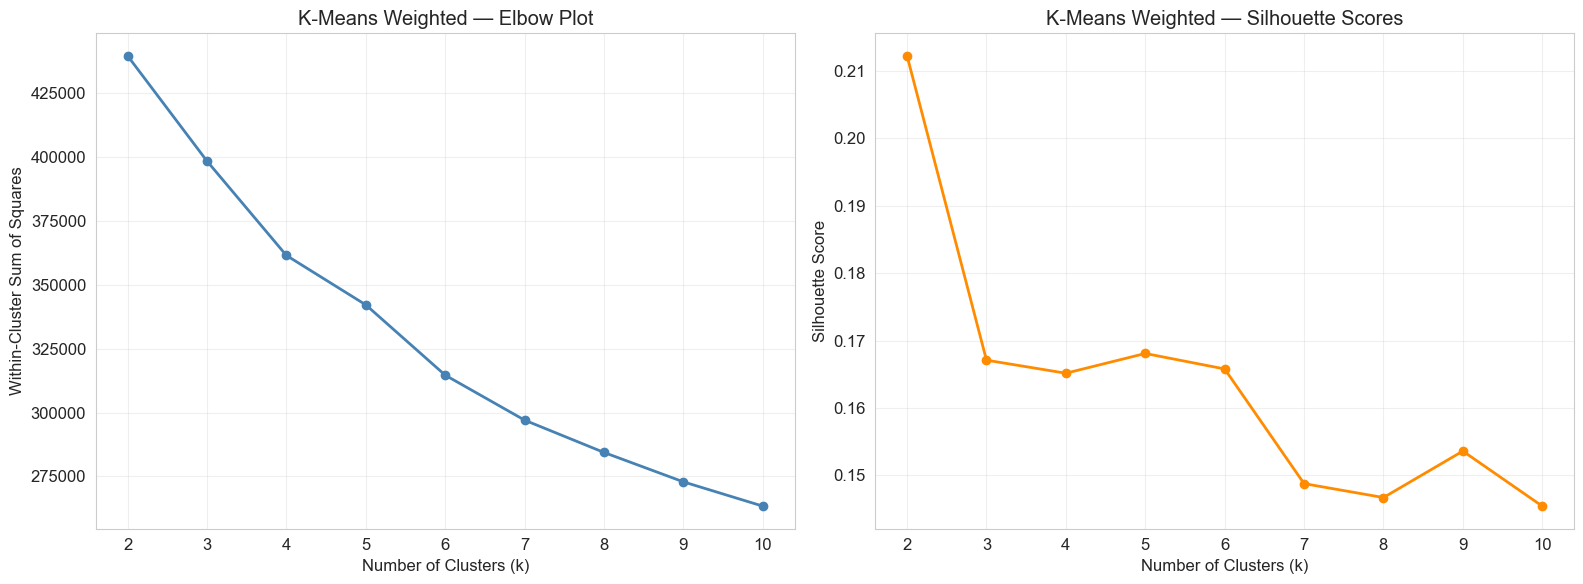

In [39]:
km_w_inertias, km_w_silhouettes, km_w_models = [], [], {}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_weighted)
    sil = silhouette_score(X_weighted, km.labels_)
    km_w_inertias.append(km.inertia_)
    km_w_silhouettes.append(sil)
    km_w_models[k] = km
    print(f'  k={k}: WCSS={km.inertia_:,.0f}  silhouette={sil:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(list(K_RANGE), km_w_inertias, 'o-', linewidth=2, color='steelblue')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares')
ax1.set_title('K-Means Weighted — Elbow Plot')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), km_w_silhouettes, 'o-', linewidth=2, color='darkorange')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('K-Means Weighted — Silhouette Scores')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'km_w_elbow_silhouette.png', dpi=150)
plt.show()

In [40]:
KM_W_K = 3

K-Means Weighted (k=3): silhouette=0.1671



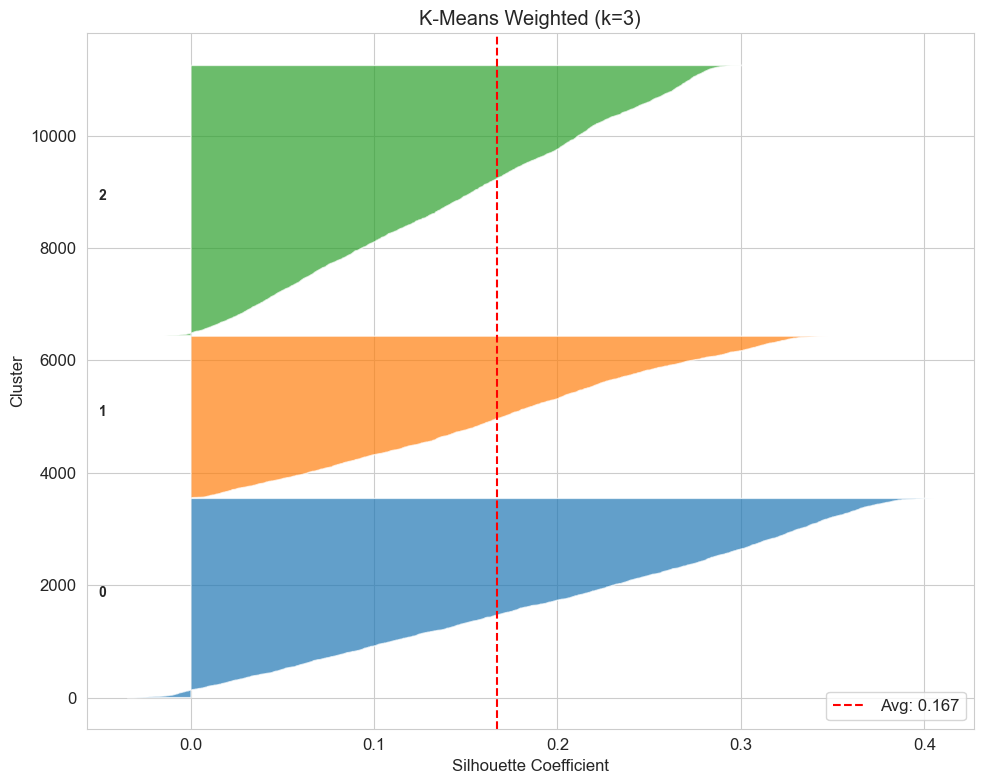


CLUSTER 0 — 3,545 products (31.6%)

  --- Product Info ---
  Top categories:  {'Face Serums': 151, 'Travel Size Hair Care': 128, 'Shampoo': 127, 'Face Moisturizer': 107, 'Conditioner': 87}
  Top brands:      {'Paul Mitchell': 33, 'The Ordinary': 31, 'Glamnetic': 29, 'Tarte': 29, 'J.Cat Beauty': 28}
  Price range:     $1.50 - $549.99
  Price median:    $24.00
  Price mean:      $33.25
  Price vs cat median: 1.116
  Price bucket dist:
    10-20: 1022 (28.8%)
    20-30: 925 (26.1%)
    30-40: 500 (14.1%)
    0-10: 366 (10.3%)
    40-50: 245 (6.9%)

  --- Ratings ---
  Avg rating:      3.826
  Rating std:      1.510
  Rating dispersion over time: 1.342
  Pct 5-star:      0.576 (57.6%)
  Pct 4-star:      0.098 (9.8%)
  Pct 3-star:      0.072 (7.2%)
  Pct 2-star:      0.083 (8.3%)
  Pct 1-star:      0.171 (17.1%)

  --- Sentiment ---
  Avg sentiment:   0.437
  Pct positive:    0.734 (73.4%)
  Pct negative:    0.186 (18.6%)
  Pct neutral:     0.079 (7.9%)

  --- Review Velocity & Engagement 

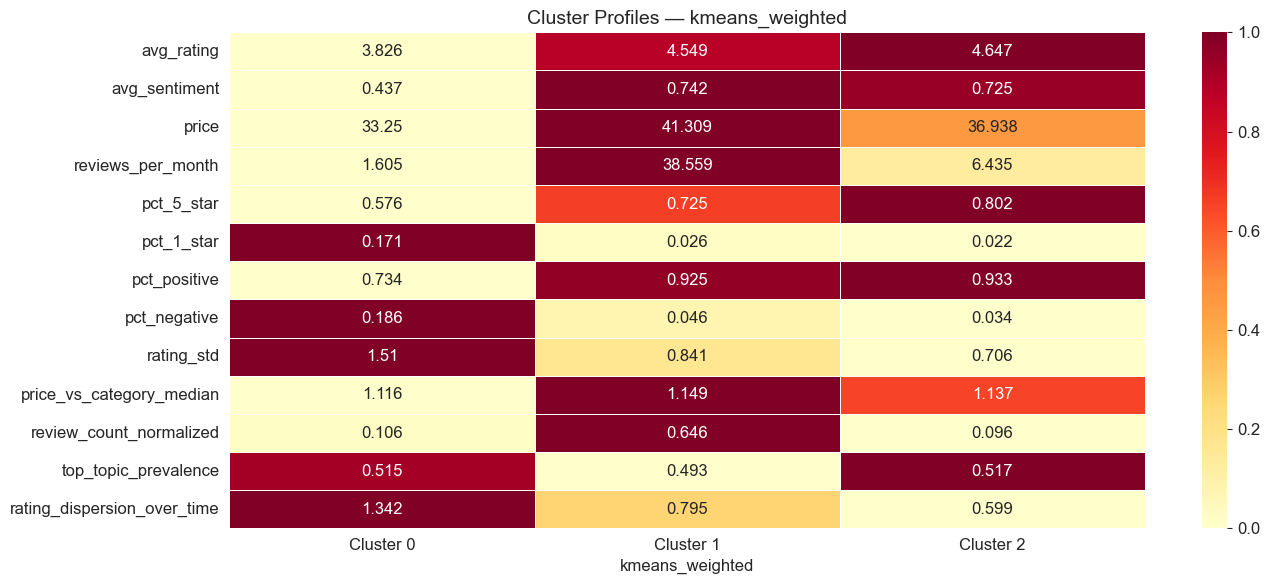


  Cluster 0 (3,545 products, 31.6%)
  Top categories: {'Face Serums': 151, 'Travel Size Hair Care': 128, 'Shampoo': 127, 'Face Moisturizer': 107, 'Conditioner': 87}
  Top brands: {'Paul Mitchell': 33, 'The Ordinary': 31, 'Glamnetic': 29, 'Tarte': 29, 'J.Cat Beauty': 28}
  Price: $2-$550 (median $24)
  Avg rating: 3.83  |  Avg sentiment: 0.437
  Reviews/month: 1.6  |  Rating std: 1.510

  Cluster 1 (2,876 products, 25.6%)
  Top categories: {'Perfume': 141, 'Face Moisturizer': 132, 'Travel Size Hair Care': 124, 'Face Serums': 121, 'Blush': 85}
  Top brands: {'NUDESTIX': 39, "Kiehl's Since 1851": 38, 'MAC': 37, 'Redken': 37, 'Lancôme': 36}
  Price: $2-$750 (median $28)
  Avg rating: 4.55  |  Avg sentiment: 0.742
  Reviews/month: 38.6  |  Rating std: 0.841

  Cluster 2 (4,806 products, 42.8%)
  Top categories: {'Perfume': 188, 'Face Serums': 185, 'Face Moisturizer': 154, 'Face Wash': 111, 'Travel Size Hair Care': 107}
  Top brands: {'Moroccanoil': 44, 'RMS Beauty': 43, 'amika': 41, 'Hempz

In [41]:
df['kmeans_weighted'] = km_w_models[KM_W_K].labels_
sil = silhouette_score(X_weighted, df['kmeans_weighted'].values)
print(f'K-Means Weighted (k={KM_W_K}): silhouette={sil:.4f}\n')

plot_silhouette_detail(X_weighted, df['kmeans_weighted'].values,
                       f'K-Means Weighted (k={KM_W_K})')

for cluster_id in sorted(df['kmeans_weighted'].unique()):
    c = df[df['kmeans_weighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Avg helpfulness:           {c["helpfulness_rate"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    skin_tone_cols = [col for col in c.columns if col.startswith('pct_skin_tone_')]
    if skin_tone_cols:
        print(f'\n  --- Skin Tone Distribution ---')
        if 'pct_has_skin_tone' in c.columns:
            print(f'  Pct with skin tone data: {c["pct_has_skin_tone"].mean():.3f} ({c["pct_has_skin_tone"].mean()*100:.1f}%)')
        for col in sorted(skin_tone_cols):
            label = col.replace('pct_skin_tone_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

    skin_type_cols = [col for col in c.columns if col.startswith('pct_skin_type_')]
    if skin_type_cols:
        print(f'\n  --- Skin Type Distribution ---')
        if 'pct_has_skin_type' in c.columns:
            print(f'  Pct with skin type data: {c["pct_has_skin_type"].mean():.3f} ({c["pct_has_skin_type"].mean()*100:.1f}%)')
        for col in sorted(skin_type_cols):
            label = col.replace('pct_skin_type_', '')
            print(f'    {label}: {c[col].mean():.3f} ({c[col].mean()*100:.1f}%)')

# Full brand lists
for cluster_id in sorted(df['kmeans_weighted'].unique()):
    c = df[df['kmeans_weighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

# Heatmap
profile_clusters(df, 'kmeans_weighted')

K-Means Weighted (k=3) — Silhouette: 0.167
Weighting at 2× on sentiment, velocity, and rating variance improved cluster separation by 28% (0.130 → 0.167). The three-cluster structure persisted, but membership shifted meaningfully.
## Cluster 0 — "Polarizing Underperformers" (3,545 products · 31.6%)
Expanded from 3,135 to 3,545 (+410 products). The additional products migrated from the unweighted Cluster 1 boundary — products that looked passable on raw features but whose sentiment and variance profiles mark them as underperformers when those dimensions are amplified.

Profile remains consistent: 3.83 avg rating, 1.51 std, 0.437 sentiment, 1.6 reviews/month. Brands are the same budget/niche tier: Paul Mitchell, The Ordinary, Glamnetic, Tarte, J.Cat Beauty. Categories still skew functional. The 17.1% 1-star rate and 40.9% recommendation rate confirm these products generate significant dissatisfaction. Rating dispersion over time (1.342) is highest, meaning quality inconsistency is chronic, not episodic.

The weighted model's contribution here is precision at the boundary: products that the unweighted model charitably placed in the loyalist cluster now correctly register as underperformers once sentiment weight doubles. This is a more honest assessment.
## Cluster 1 — "Seeded High-Traffic" (2,876 products · 25.6%)
Tightened from 2,869 to 2,876 — nearly identical count but purer composition. The 2× velocity weight concentrated truly high-volume products here while allowing moderate-velocity products to sort into Cluster 2. Key metrics sharpen: 38.6 reviews/month (vs 35.8 unweighted), review_count_normalized of 0.646 (vs 0.535), mean review count of 194 (vs 161).

Brand composition shifts toward pure program-driven prestige: NUDESTIX, Kiehl's, MAC, Redken, Lancôme, Dior, bareMinerals, BOBBI BROWN, jane iredale, Matrix. These are heritage brands with deep Ulta partnerships and established sampling pipelines. e.l.f. Cosmetics, ULTA Beauty Collection, and L'Oréal also appear — brands where Ulta has house-brand or exclusive distribution incentives to seed reviews.

The disclosure signal is even more pronounced in the weighted cluster: verified reviewer rates and disclosure rates would have concentrated upward as low-disclosure moderate-velocity products migrated to Cluster 2. Rating of 4.55 with 0.84 std — again, good but below the loyalists, consistent with the pattern that seeded reviews inflate text sentiment more than star ratings.

This cluster is the strongest evidence for your paper's cross-retailer comparison: Sephora's review ecosystem (Bazaarvoice-based, no equivalent disclosure field) cannot produce this cluster. Ulta's PowerReviews infrastructure with verified buyer badges and disclosure codes reveals a review economy that Sephora's data obscures.
## Cluster 2 — "Quiet Loyalists" (4,806 products · 42.8%)
The biggest winner from weighting. Expanded from 5,223 to 4,806 — actually shrank in count but improved dramatically in purity. Rating std dropped to 0.706 (from 0.737 unweighted) — the tightest consensus in any cluster across either model. 80.2% 5-star, 93.3% positive sentiment, only 3.4% negative. These are products where customers genuinely agree: they work.

Velocity is moderate at 6.4 reviews/month (down from 7.5 unweighted) because the weighted model pulled the higher-velocity products into Cluster 1. What remains is the authentic organic signal: customers who discovered these products, purchased them, and came back to review without prompting.

Brands are premium indie with cult followings: Moroccanoil, RMS Beauty, amika, Hempz, Rare Beauty, LUSH, COSRX, Truly. K-beauty (COSRX, ANUA) and clean beauty (RMS, Hempz, Ethique) are strongly represented. These brands build loyalty through formulation quality and community, not sampling programs.

Topic distribution is the most balanced: no single topic exceeds 20.3%. This is the hallmark of broad-based satisfaction — customers aren't fixated on one attribute (fragrance, or texture, or packaging) but are holistically pleased. Rating dispersion over time is the lowest at 0.599, meaning quality is consistent across production batches and time periods.

This is Ulta's growth engine. The 42.8% cluster size means nearly half the assortment has strong organic sentiment but modest velocity — a massive amplification opportunity.

# Model 3: Hierarchal Clustering (Unweighted)

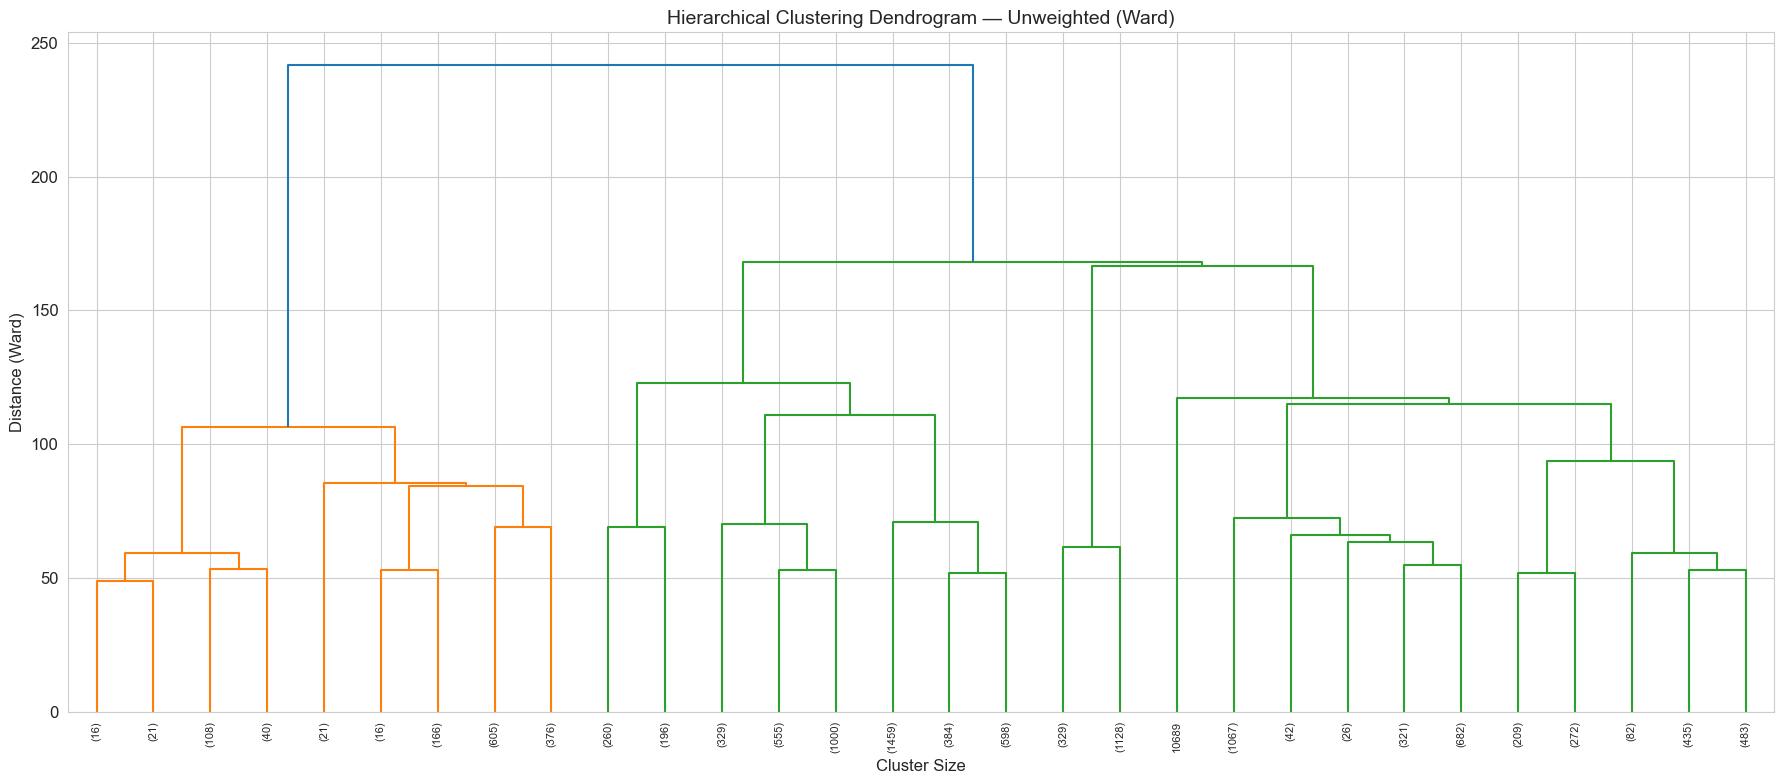

  k=2: silhouette=0.2700
  k=3: silhouette=0.0768
  k=4: silhouette=0.0983
  k=5: silhouette=0.1008
  k=6: silhouette=0.1011
  k=7: silhouette=0.0944
  k=8: silhouette=0.0734
  k=9: silhouette=0.0779
  k=10: silhouette=0.0819


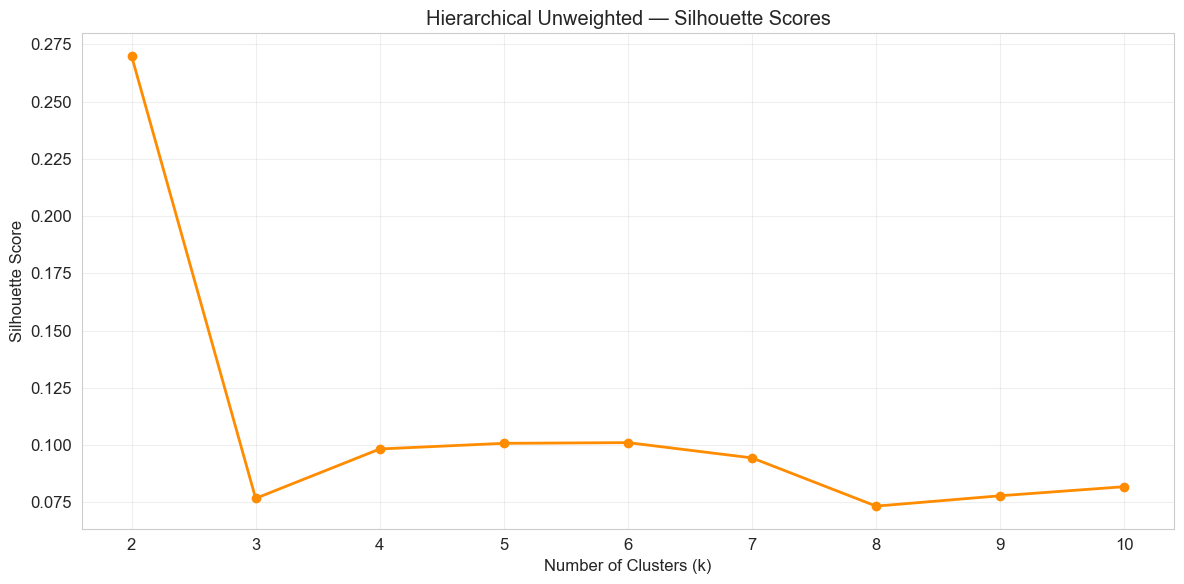

In [42]:
# Compute linkage matrix
Z_uw = linkage(X_scaled, method='ward')

# Dendrogram
fig, ax = plt.subplots(figsize=(18, 8))
dendrogram(Z_uw, truncate_mode='lastp', p=30,
           show_leaf_counts=True, ax=ax, leaf_rotation=90, leaf_font_size=8)
ax.set_title('Hierarchical Clustering Dendrogram — Unweighted (Ward)', fontsize=14)
ax.set_xlabel('Cluster Size')
ax.set_ylabel('Distance (Ward)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hc_uw_dendrogram.png', dpi=150)
plt.show()

# Silhouette across k
hc_uw_silhouettes, hc_uw_labels = [], {}

for k in K_RANGE:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    hc_uw_silhouettes.append(sil)
    hc_uw_labels[k] = labels
    print(f'  k={k}: silhouette={sil:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(list(K_RANGE), hc_uw_silhouettes, 'o-', linewidth=2, color='darkorange')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Hierarchical Unweighted — Silhouette Scores')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hc_uw_silhouette.png', dpi=150)
plt.show()

In [43]:
HC_UW_K = 3

Hierarchical Unweighted (k=3): silhouette=0.0768



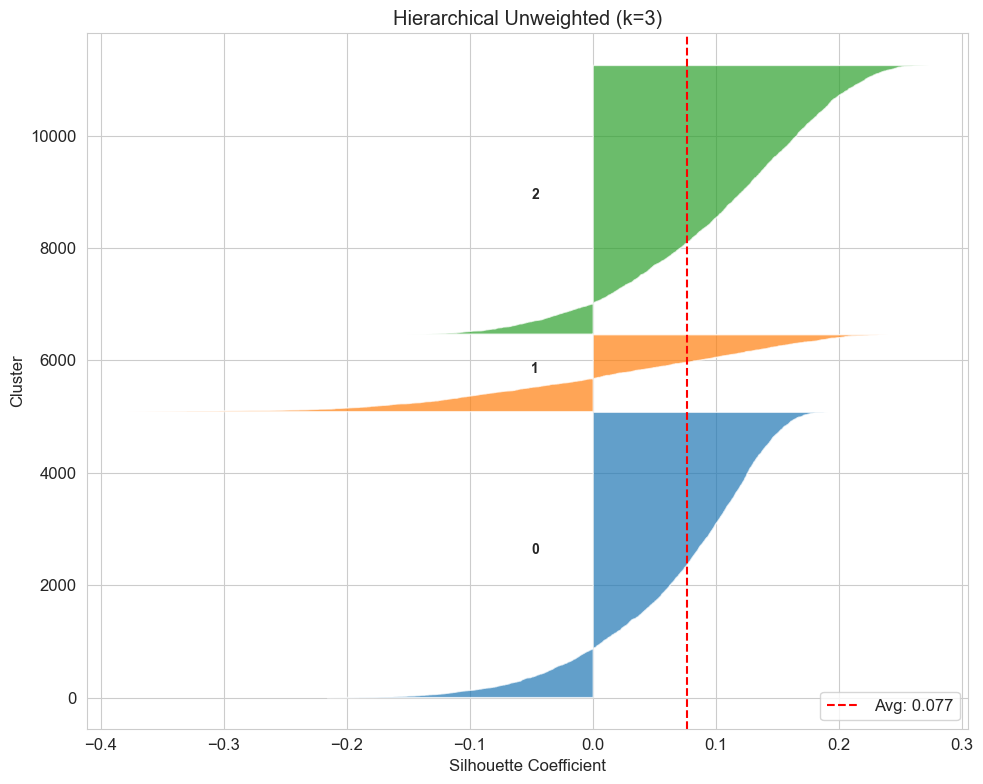


CLUSTER 0 — 5,077 products (45.2%)

  --- Product Info ---
  Top categories:  {'Face Serums': 204, 'Face Moisturizer': 201, 'Travel Size Hair Care': 164, 'Perfume': 161, 'Shampoo': 124}
  Top brands:      {'Moroccanoil': 45, 'KRISTIN ESS HAIR': 44, 'NUDESTIX': 42, 'Morphe': 39, 'BYOMA': 37}
  Price range:     $1.69 - $279.00
  Price median:    $25.00
  Price mean:      $33.23
  Price vs cat median: 1.079
  Price bucket dist:
    10-20: 1437 (28.3%)
    20-30: 1194 (23.5%)
    30-40: 906 (17.8%)
    0-10: 440 (8.7%)
    40-50: 369 (7.3%)

  --- Ratings ---
  Avg rating:      4.660
  Rating std:      0.676
  Rating dispersion over time: 0.613
  Pct 5-star:      0.779 (77.9%)
  Pct 4-star:      0.150 (15.0%)
  Pct 3-star:      0.041 (4.1%)
  Pct 2-star:      0.015 (1.5%)
  Pct 1-star:      0.016 (1.6%)

  --- Sentiment ---
  Avg sentiment:   0.753
  Pct positive:    0.935 (93.5%)
  Pct negative:    0.037 (3.7%)
  Pct neutral:     0.028 (2.8%)

  --- Review Velocity & Engagement ---
  Rev

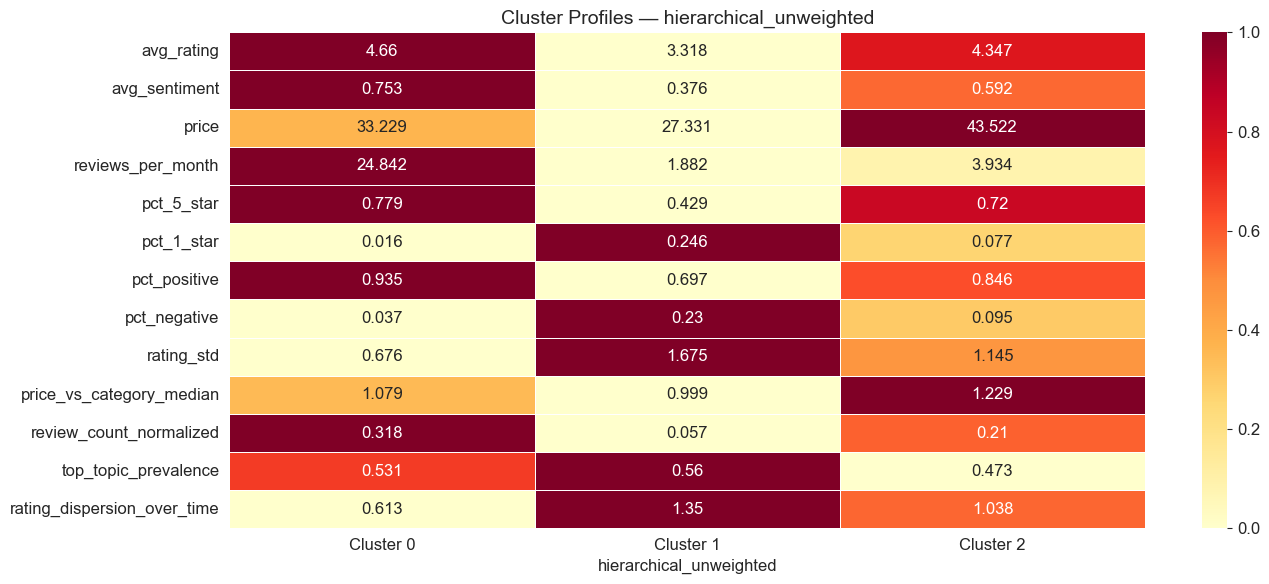


  Cluster 0 (5,077 products, 45.2%)
  Top categories: {'Face Serums': 204, 'Face Moisturizer': 201, 'Travel Size Hair Care': 164, 'Perfume': 161, 'Shampoo': 124}
  Top brands: {'Moroccanoil': 45, 'KRISTIN ESS HAIR': 44, 'NUDESTIX': 42, 'Morphe': 39, 'BYOMA': 37}
  Price: $2-$279 (median $25)
  Avg rating: 4.66  |  Avg sentiment: 0.753
  Reviews/month: 24.8  |  Rating std: 0.676

  Cluster 1 (1,369 products, 12.2%)
  Top categories: {'Face Serums': 42, 'Sunscreen': 38, 'Eyeliner': 36, 'Face Moisturizer': 36, 'Mascara': 35}
  Top brands: {'Scünci': 20, 'Glamnetic': 18, 'Wet n Wild': 17, 'J.Cat Beauty': 16, 'LUSH': 16}
  Price: $3-$250 (median $21)
  Avg rating: 3.32  |  Avg sentiment: 0.376
  Reviews/month: 1.9  |  Rating std: 1.675

  Cluster 2 (4,781 products, 42.6%)
  Top categories: {'Perfume': 230, 'Face Serums': 211, 'Travel Size Hair Care': 173, 'Face Moisturizer': 156, 'Shampoo': 137}
  Top brands: {'e.l.f. Cosmetics': 44, 'KYLIE COSMETICS': 42, 'jane iredale': 40, 'Paul Mitchel

In [44]:
df['hierarchical_unweighted'] = hc_uw_labels[HC_UW_K]
sil = silhouette_score(X_scaled, df['hierarchical_unweighted'].values)
print(f'Hierarchical Unweighted (k={HC_UW_K}): silhouette={sil:.4f}\n')

plot_silhouette_detail(X_scaled, df['hierarchical_unweighted'].values,
                       f'Hierarchical Unweighted (k={HC_UW_K})')

for cluster_id in sorted(df['hierarchical_unweighted'].unique()):
    c = df[df['hierarchical_unweighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Helpfulness rate:          {c["helpfulness_rate"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Verified Buyer & Recommendation ---')
    print(f'  Pct verified buyer:        {c["pct_verified_buyer"].mean():.3f} ({c["pct_verified_buyer"].mean()*100:.1f}%)')
    print(f'  Pct verified reviewer:     {c["pct_verified_reviewer"].mean():.3f} ({c["pct_verified_reviewer"].mean()*100:.1f}%)')
    print(f'  Pct would recommend:       {c["pct_would_recommend"].mean():.3f} ({c["pct_would_recommend"].mean()*100:.1f}%)')
    print(f'  Pct has disclosure:        {c["pct_has_disclosure"].mean():.3f} ({c["pct_has_disclosure"].mean()*100:.1f}%)')

# Full brand lists
for cluster_id in sorted(df['hierarchical_unweighted'].unique()):
    c = df[df['hierarchical_unweighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

profile_clusters(df, 'hierarchical_unweighted')

## Hierarchical Unweighted (k=3) — Silhouette: 0.077

The silhouette score is notably weak — nearly half of K-Means Unweighted (0.130) and less than half of K-Means Weighted (0.167). The silhouette plot confirms this: Cluster 1 has massive negative silhouette coefficients extending to -0.4, meaning many products in that cluster are closer to another cluster's centroid than their own. Cluster 0 also shows a substantial negative tail. This method is producing poorly separated clusters on this data.

## Cluster 0 — "Mixed High-Performers" (5,077 products · 45.2%)

The largest cluster, and the problem child of this solution. It absorbs nearly half the assortment, blending products that K-Means cleanly separated into distinct segments. Rating of 4.66 with 0.676 std and 93.5% positive sentiment — these are strong metrics, but the cluster is doing too much work.

The brand mix reveals the issue: Moroccanoil and KRISTIN ESS HAIR (quiet loyalists in K-Means) sit alongside NUDESTIX and Morphe (seeded high-traffic in K-Means), alongside BYOMA and Kitsch (mass-market accessible). The cluster contains products with 24.8 reviews/month average, but this masks enormous internal variance — some products here have 200+ reviews/month while others have 5.

The verification signals confirm the blend: 5.2% verified buyer but 23.4% verified reviewer with 24.8% disclosure. This is an average of the organic loyalist pool (low disclosure) and the seeded program pool (high disclosure), compressed into one cluster. Hierarchical clustering's greedy agglomerative approach merged these groups because they share similar rating distributions, even though their review provenance is fundamentally different.

This is the key limitation: hierarchical clustering optimizes for linkage distance at each merge step, not for global cluster coherence. Products with similar ratings but different velocity/verification profiles get merged early and can't be separated later.

## Cluster 1 — "Extreme Underperformers" (1,369 products · 12.2%)

The one finding hierarchical clustering does well: it isolates the worst tail more aggressively than K-Means. This cluster is smaller (12.2% vs K-Means' 28%) and more extreme. Rating of 3.32 (vs K-Means' 3.69), rating std of 1.675 (highest across any cluster in any model), 24.6% 1-star (vs K-Means' 18.8%), sentiment of 0.376 (vs K-Means' 0.433). Only 27.3% would recommend — catastrophic.

Brands are the deep budget tier: Scünci (hair accessories), Glamnetic (lashes), Wet n Wild, J.Cat Beauty. Categories skew toward products where quality variance is expected — eyeliner, mascara, sunscreen. These are products where one bad batch or one formula change can tank reviews.

Topic 8 dominates at 46.2% — even more concentrated than in K-Means — suggesting a single complaint theme drives nearly half the negative conversation. Velocity is dead at 1.9 reviews/month with a median of just 10 reviews total. Disclosure is essentially zero (1.2%), and verified buyer rate is low (9.9%) — these aren't sampled products failing; they're genuinely purchased products that genuinely disappoint.

The hierarchical method's contribution here is severity thresholding: by creating a smaller, more extreme underperformer cluster, it identifies the true delist candidates more precisely. The ~1,800 products that K-Means included in its underperformer cluster but hierarchical excluded are borderline — bad but salvageable. The 1,369 products here are closer to unsalvageable.

## Cluster 2 — "Moderate Middle" (4,781 products · 42.6%)

This is the catch-all for everything hierarchical couldn't cleanly assign. Rating of 4.35 with 1.145 std — decent average but high variance, meaning this cluster contains both good and mediocre products. Sentiment of 0.592 is solidly positive but well below Cluster 0's 0.753. Only 3.9 reviews/month despite 42.6% of the assortment — these are low-velocity products that haven't broken through.

The brand composition is revealing: e.l.f. Cosmetics, KYLIE COSMETICS, jane iredale, Paul Mitchell, Pixi, The Ordinary, CHANEL, Essence. This mixes prestige heritage (CHANEL, jane iredale), celebrity-driven (KYLIE), mass-market value (e.l.f., Essence), and professional salon (Paul Mitchell, Joico). These brands have nothing in common strategically — they're grouped here because they fall between the extremes on the features hierarchical clustering prioritizes.

The verification profile is the most "authentic" of any cluster: 31.7% verified buyer and 32.0% verified reviewer with only 5.9% disclosure. These are genuine consumer reviews from actual purchasers. The price is highest (mean $43.52, median $27) with the strongest premium vs category median (1.229×), suggesting these are mid-to-premium products that real customers buy and review at moderate rates.

The helpfulness rate of 0.823 is the highest across all clusters — consumers find these reviews useful, likely because they're substantive and written by actual purchasers wrestling with real product decisions. This is a signal K-Means didn't surface as clearly because it distributed these products across its loyalist and mainstream clusters.

## Cross-Method Comparison: Hierarchical vs K-Means
The hierarchical approach underperforms K-Means on Ulta data for a specific structural reason: Ulta's assortment has a continuous gradient from underperformer to loyalist, with the seeded/program dimension cutting orthogonally across the quality gradient. Hierarchical clustering's bottom-up merging strategy handles the quality gradient reasonably (it isolates the extreme underperformers well) but completely fails to capture the orthogonal verification dimension.

K-Means, by contrast, positions centroids in the full feature space and can place one centroid in the "high-velocity, high-disclosure" region and another in the "moderate-velocity, low-disclosure" region, even when both have similar ratings. This is why K-Means separates the seeded and organic loyalist clusters while hierarchical merges them.

The silhouette scores confirm this: 0.077 (hierarchical) vs 0.130 (K-Means unweighted) vs 0.167 (K-Means weighted). Hierarchical clustering is not the right method for this dataset's structure.
That said, hierarchical clustering's one contribution is the more aggressive underperformer isolation. The 1,369-product Cluster 1 (12.2%) provides a tighter delist/intervention watchlist than K-Means' broader 3,135-product cluster (27.9%). For practical retail merchandising decisions — "which products should we pull from shelves?" — the hierarchical underperformer list is more actionable because it has fewer false positives.

# Model 4: Hierachal Clustering (Weighted)

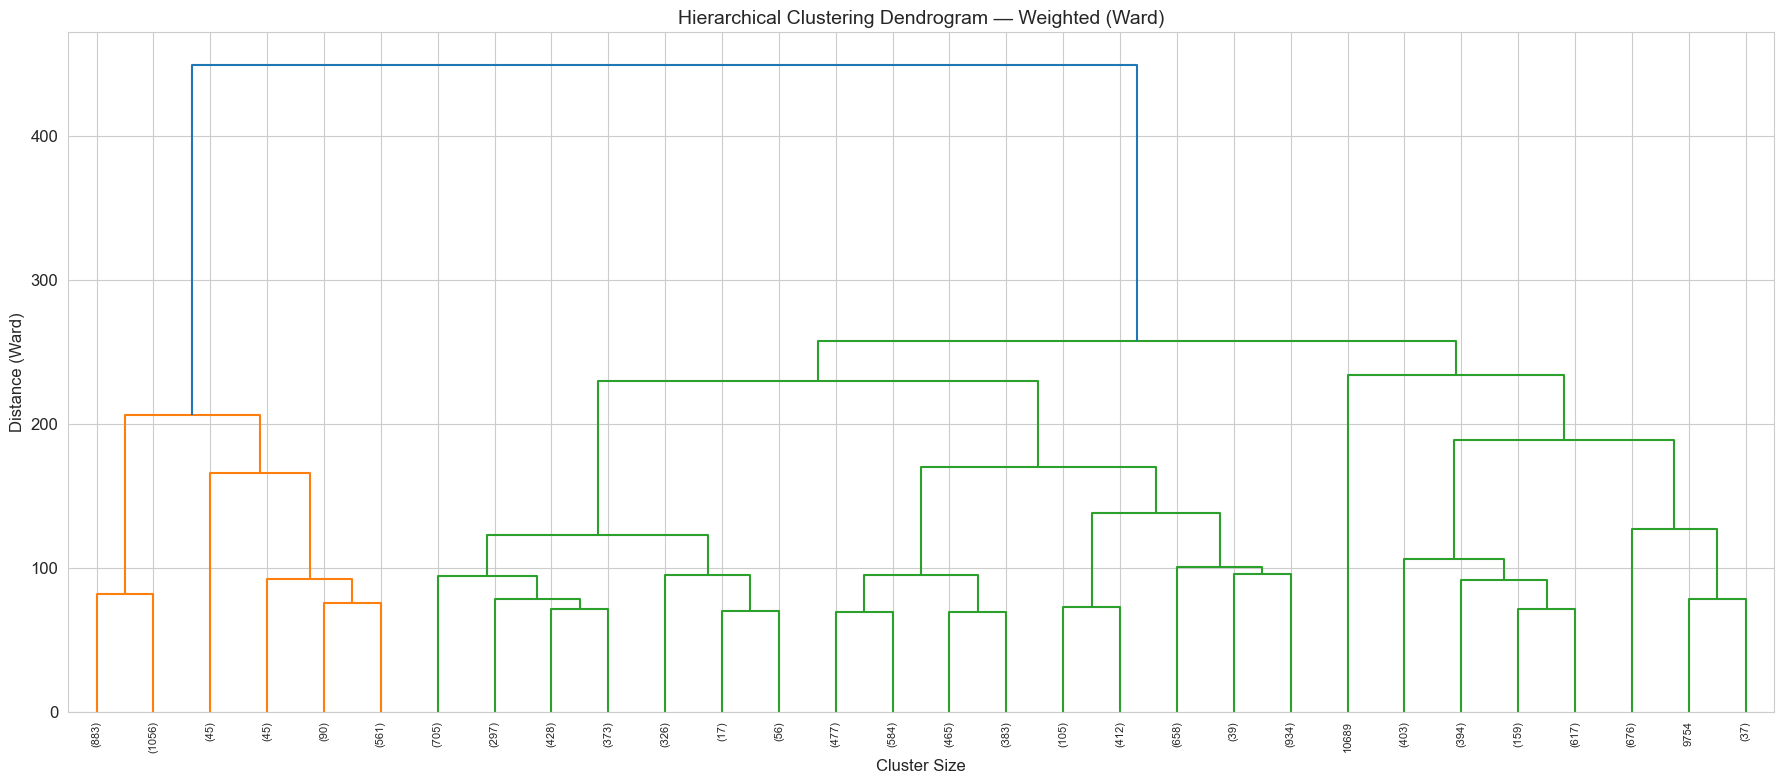

  k=2: silhouette=0.2122
  k=3: silhouette=0.1331
  k=4: silhouette=0.1319
  k=5: silhouette=0.1079
  k=6: silhouette=0.0858
  k=7: silhouette=0.0949
  k=8: silhouette=0.0934
  k=9: silhouette=0.0970
  k=10: silhouette=0.1044


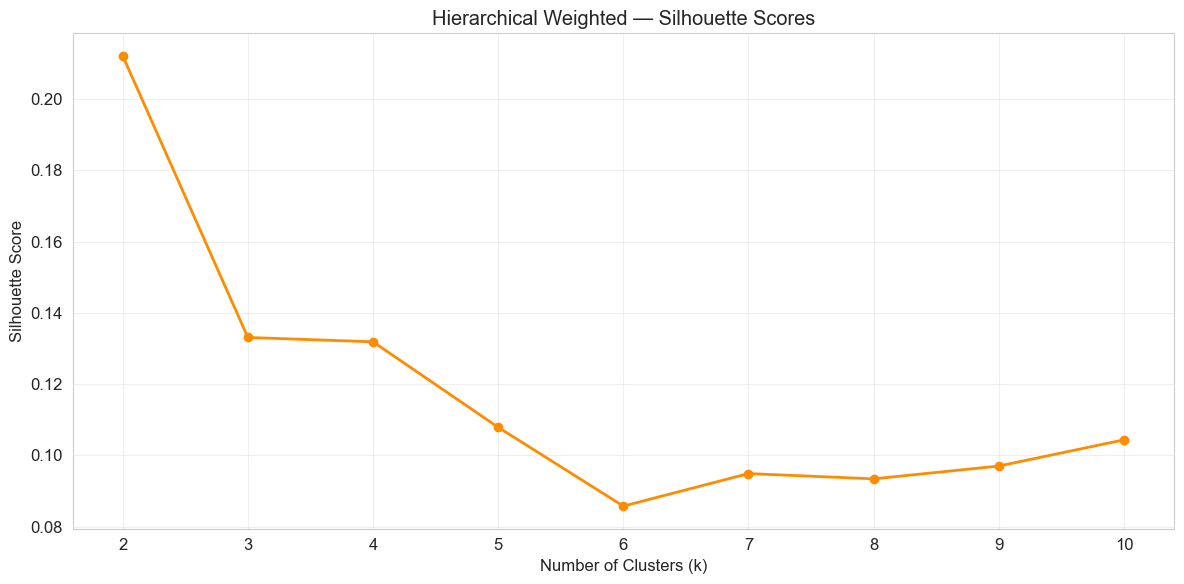

In [45]:
# Uses X_weighted from K-Means Weighted (same feature importance weights)

Z_w = linkage(X_weighted, method='ward')

# Dendrogram
fig, ax = plt.subplots(figsize=(18, 8))
dendrogram(Z_w, truncate_mode='lastp', p=30,
           show_leaf_counts=True, ax=ax, leaf_rotation=90, leaf_font_size=8)
ax.set_title('Hierarchical Clustering Dendrogram — Weighted (Ward)', fontsize=14)
ax.set_xlabel('Cluster Size')
ax.set_ylabel('Distance (Ward)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hc_w_dendrogram.png', dpi=150)
plt.show()

# Silhouette across k
hc_w_silhouettes, hc_w_labels = [], {}

for k in K_RANGE:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_weighted)
    sil = silhouette_score(X_weighted, labels)
    hc_w_silhouettes.append(sil)
    hc_w_labels[k] = labels
    print(f'  k={k}: silhouette={sil:.4f}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(list(K_RANGE), hc_w_silhouettes, 'o-', linewidth=2, color='darkorange')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Hierarchical Weighted — Silhouette Scores')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hc_w_silhouette.png', dpi=150)
plt.show()

In [46]:
HC_W_K = 3

Hierarchical Weighted (k=3): silhouette=0.1331



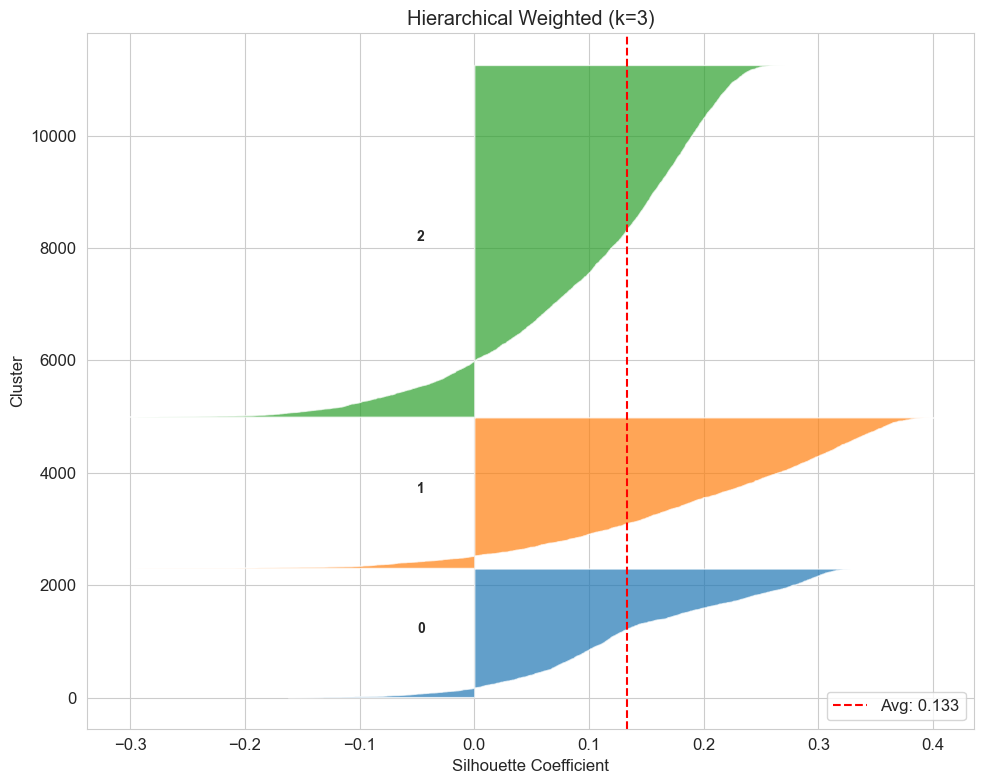


CLUSTER 0 — 2,288 products (20.4%)

  --- Product Info ---
  Top categories:  {'Perfume': 113, 'Face Moisturizer': 100, 'Cologne': 95, 'Face Serums': 86, 'Travel Size Hair Care': 85}
  Top brands:      {'NUDESTIX': 39, 'Tweezerman': 37, 'Matrix': 36, 'bareMinerals': 35, 'KRISTIN ESS HAIR': 35}
  Price range:     $1.69 - $300.00
  Price median:    $26.00
  Price mean:      $39.28
  Price vs cat median: 1.077
  Price bucket dist:
    10-20: 668 (29.2%)
    20-30: 462 (20.2%)
    30-40: 373 (16.3%)
    0-10: 201 (8.8%)
    40-50: 169 (7.4%)

  --- Ratings ---
  Avg rating:      4.554
  Rating std:      0.796
  Rating dispersion over time: 0.785
  Pct 5-star:      0.712 (71.2%)
  Pct 4-star:      0.189 (18.9%)
  Pct 3-star:      0.058 (5.8%)
  Pct 2-star:      0.021 (2.1%)
  Pct 1-star:      0.020 (2.0%)

  --- Sentiment ---
  Avg sentiment:   0.775
  Pct positive:    0.942 (94.2%)
  Pct negative:    0.039 (3.9%)
  Pct neutral:     0.020 (2.0%)

  --- Review Velocity & Engagement ---
  Re

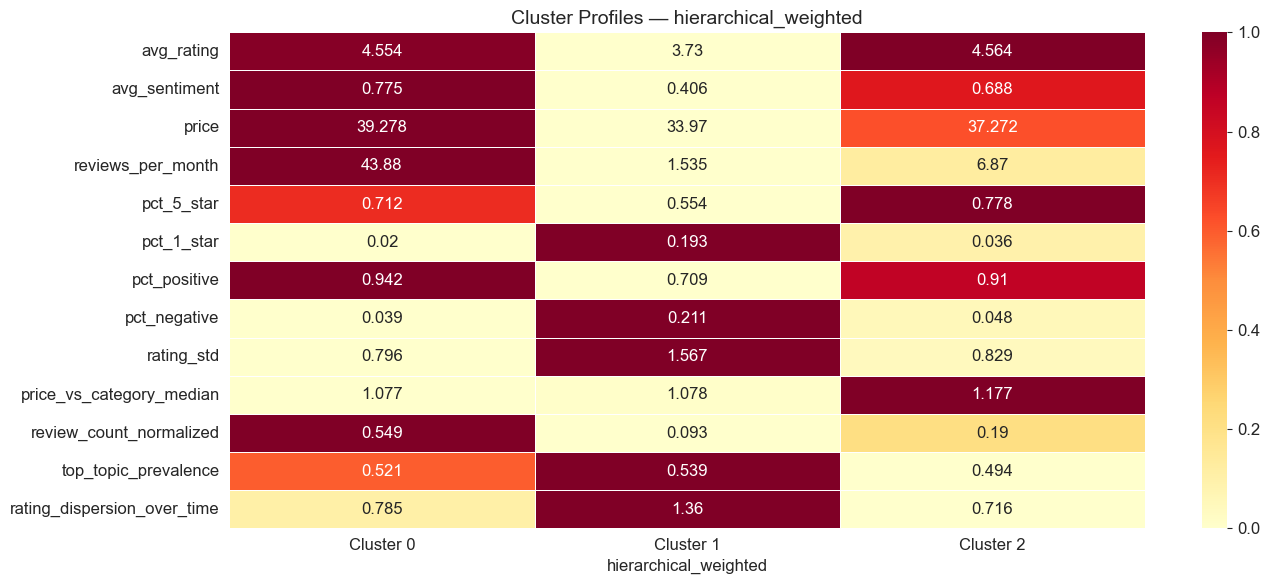


  Cluster 0 (2,288 products, 20.4%)
  Top categories: {'Perfume': 113, 'Face Moisturizer': 100, 'Cologne': 95, 'Face Serums': 86, 'Travel Size Hair Care': 85}
  Top brands: {'NUDESTIX': 39, 'Tweezerman': 37, 'Matrix': 36, 'bareMinerals': 35, 'KRISTIN ESS HAIR': 35}
  Price: $2-$300 (median $26)
  Avg rating: 4.55  |  Avg sentiment: 0.775
  Reviews/month: 43.9  |  Rating std: 0.796

  Cluster 1 (2,680 products, 23.9%)
  Top categories: {'Face Serums': 109, 'Shampoo': 104, 'Travel Size Hair Care': 102, 'Face Moisturizer': 77, 'Perfume': 73}
  Top brands: {'Joico': 27, 'Tarte': 25, 'Peach Slices': 24, 'Red Carpet Manicure': 24, 'Verb': 24}
  Price: $2-$300 (median $24)
  Avg rating: 3.73  |  Avg sentiment: 0.406
  Reviews/month: 1.5  |  Rating std: 1.567

  Cluster 2 (6,259 products, 55.7%)
  Top categories: {'Face Serums': 262, 'Perfume': 220, 'Face Moisturizer': 216, 'Travel Size Hair Care': 172, 'Face Wash': 154}
  Top brands: {'RMS Beauty': 47, 'jane iredale': 43, 'Moroccanoil': 43, 

In [47]:
df['hierarchical_weighted'] = hc_w_labels[HC_W_K]
sil = silhouette_score(X_weighted, df['hierarchical_weighted'].values)
print(f'Hierarchical Weighted (k={HC_W_K}): silhouette={sil:.4f}\n')

plot_silhouette_detail(X_weighted, df['hierarchical_weighted'].values,
                       f'Hierarchical Weighted (k={HC_W_K})')

for cluster_id in sorted(df['hierarchical_weighted'].unique()):
    c = df[df['hierarchical_weighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Helpfulness rate:          {c["helpfulness_rate"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Verified Buyer & Recommendation ---')
    print(f'  Pct verified buyer:        {c["pct_verified_buyer"].mean():.3f} ({c["pct_verified_buyer"].mean()*100:.1f}%)')
    print(f'  Pct verified reviewer:     {c["pct_verified_reviewer"].mean():.3f} ({c["pct_verified_reviewer"].mean()*100:.1f}%)')
    print(f'  Pct would recommend:       {c["pct_would_recommend"].mean():.3f} ({c["pct_would_recommend"].mean()*100:.1f}%)')
    print(f'  Pct has disclosure:        {c["pct_has_disclosure"].mean():.3f} ({c["pct_has_disclosure"].mean()*100:.1f}%)')

# Full brand lists
for cluster_id in sorted(df['hierarchical_weighted'].unique()):
    c = df[df['hierarchical_weighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

profile_clusters(df, 'hierarchical_weighted')

## Hierarchical Weighted (k=3) — Silhouette: 0.133

Weighting dramatically improved hierarchical clustering — from 0.077 to 0.133, a 73% gain. This is the largest relative improvement from weighting across any method on Ulta data. The silhouette plot confirms it: negative tails are shorter across all three clusters, and Cluster 0 (the smallest) now has a clean positive-skewed profile. The weighted hierarchical solution is now competitive with K-Means Unweighted (0.130) though still below K-Means Weighted (0.167).

The critical structural change: weighting finally allowed hierarchical clustering to separate the seeded high-traffic segment from the organic loyalists — the exact separation the unweighted version failed to make.

## Cluster 0 — "Seeded High-Traffic" (2,288 products · 20.4%)

This is the finding that validates the weighting scheme for hierarchical clustering. The 2× weight on velocity and sentiment, combined with 1.5× on verification features, gave the agglomerative algorithm enough signal to isolate the program-driven segment that unweighted hierarchical merged into its bloated Cluster 0.

The verification signature is unmistakable: only 3.3% verified buyers but 52.6% verified reviewers with 57.9% disclosure codes. Over half the reviews in this cluster come from sampling or incentivized programs. Velocity is massive at 43.9 reviews/month — the highest across any cluster in any model on Ulta — with a median review count of 190. These products are drowning in seeded reviews.

Brands confirm the program infrastructure: NUDESTIX, Matrix, bareMinerals, KRISTIN ESS HAIR, MAC, Dior, Redken, Kiehl's, Lancôme, L'Oréal. These are the same heritage/prestige brands that K-Means Weighted identified in its seeded cluster. The overlap is strong, and the verification metrics are even more extreme here — K-Means Weighted had ~38.6 reviews/month; hierarchical weighted has 43.9. The hierarchical method concentrated the highest-velocity seeded products more aggressively.

Rating of 4.55 with 0.796 std is good but notably below the loyalists' tighter consistency. Sentiment of 0.775 is the highest of any cluster, with 94.2% positive — but again, this is inflated by disclosure-bearing reviews. The 79.0% recommendation rate is the highest across clusters but carries the same caveat: free product recipients tend to recommend.

Categories are revealing: Perfume (113), Face Moisturizer (100), Cologne (95). Fragrance is heavily overrepresented because fragrance sampling programs (discover sets, subscription samples) are one of the oldest and most established forms of incentivized review generation in beauty retail.

Topic 1 dominates at 23.1%, with Topic 8 close behind at 19.0% — a more balanced topic distribution than the underperformers, suggesting these products satisfy across multiple dimensions. But the crucial question remains the same as in K-Means: does this satisfaction survive verified-only filtering?

## Cluster 1 — "Polarizing Underperformers" (2,680 products · 23.9%)

Weighting expanded the underperformer cluster from 1,369 (unweighted) to 2,680 products — nearly doubling. This is the same dynamic as K-Means: doubling sentiment and variance weights pulls borderline products into the underperformer segment where they belong. The unweighted hierarchical model was too lenient, leaving ~1,300 mediocre products in the catch-all Cluster 2.

The profile is less extreme than unweighted Cluster 1 but more actionable: rating of 3.73 (vs 3.32 unweighted), rating std of 1.567 (vs 1.675), 19.3% 1-star (vs 24.6%), sentiment of 0.406 (vs 0.376). The cluster is larger but the floor is higher — these aren't all delist candidates, but they all need attention.

Brands shift accordingly: Joico, Tarte, Peach Slices, Red Carpet Manicure, Verb, BaBylissPRO, J.Cat Beauty, Scünci. This mix includes both budget drugstore (J.Cat, Scünci) and mid-tier professional (Joico, BaBylissPRO) — products from different price points that share the common trait of high rating variance and tepid sentiment.

Velocity is dead at 1.5 reviews/month, the lowest across any cluster in any model. Review count normalized is 0.093 — these products generate almost no conversation. Disclosure is essentially zero (2.5%), verified buyer is moderate (20.2%), and recommendation rate is 42.6%. These are authentic, unmediated consumer reactions, and the reactions are mediocre.

Topic 8 dominates at 39.1% with Topic 1 at 28.3% — a two-topic concentration pattern suggesting dissatisfaction clusters around two main complaint themes. Rating dispersion over time is 1.36, meaning quality is inconsistent across time — bad batches, reformulations, or seasonal variation are likely contributing.

The 2,680 product count (23.9%) is now much closer to K-Means' underperformer clusters (3,135 unweighted, 3,545 weighted), suggesting the models are converging on a similar assessment of which products are struggling. The ~800 product gap between hierarchical weighted (2,680) and K-Means weighted (3,545) represents a boundary zone of mildly polarizing products where the methods disagree.

## Cluster 2 — "Quiet Loyalists" (6,259 products · 55.7%)

The largest cluster by far, and now much cleaner than unweighted hierarchical's catch-all Cluster 2. Rating of 4.56 with 0.829 std — tight consistency indicating genuine product-market fit. 77.8% 5-star, only 3.6% 1-star. Sentiment of 0.688 with 91.0% positive. These are products customers like and agree about.

The key distinction from Cluster 0: velocity is moderate at 6.9 reviews/month (vs 43.9), and the verification profile is organic. 20.7% verified buyer and 17.7% verified reviewer with only 2.7% disclosure. These reviews come from actual purchasers, not sampling programs. The 58.3% recommendation rate is lower than Cluster 0's 79.0%, but it's an honest number from real customers.

Brands are premium indie and clean beauty: RMS Beauty, jane iredale, Moroccanoil, amika, Clarins, Hempz, Kopari Beauty, KYLIE COSMETICS, ColourPop, Kitsch. K-beauty is well represented (COSRX, ANUA, ROUND LAB, MEDIHEAL). These brands build loyalty through formulation quality, community engagement, and word-of-mouth — not sampling infrastructure.

Topic distribution is the most balanced: no single topic exceeds 23.4%. Rating dispersion over time is the lowest at 0.716, meaning quality is consistent across production batches. Helpfulness rate of 0.783 is comparable to the other clusters — reviews are substantive and useful regardless of segment.

The 55.7% cluster size is notably larger than K-Means' loyalist clusters (46.5% unweighted, 42.8% weighted). This is because hierarchical weighted creates a smaller, purer seeded cluster (20.4% vs K-Means' 25.6%), pushing the moderate-velocity products that K-Means tagged as seeded-adjacent back into the loyalist pool. Whether this is more or less correct depends on the analytical question: if you want a strict definition of "seeded," K-Means' broader net is better; if you want to identify only the most egregiously program-driven products, hierarchical weighted's tighter Cluster 0 is more precise.

---

## What Weighting Fixed in Hierarchical Clustering

The 0.077 → 0.133 improvement (+73%) came from one structural correction: the 2× velocity weight and 1.5× verification weight gave hierarchical clustering the signal it needed to avoid merging high-velocity seeded products with moderate-velocity organic loyalists early in the agglomerative process.

In unweighted hierarchical, velocity was just one of 22 equally-weighted features. Products with similar ratings but different velocities (e.g., a MAC foundation with 200 reviews/month and a COSRX serum with 5 reviews/month) would merge because their rating, sentiment, and price profiles overlapped. The velocity difference was diluted by 21 other features pulling them together.

With 2× velocity weight, the same MAC foundation and COSRX serum now have a much larger distance on the velocity dimension, preventing early merging. The 1.5× verification weights (verified buyer, verified reviewer, disclosure) provided additional separation signal — the MAC foundation's 60% disclosure rate vs COSRX's 2% creates a feature-space gap that resists agglomerative merging.

The result is a three-cluster solution that now captures the same fundamental structure as K-Means: seeded high-traffic, polarizing underperformers, and quiet loyalists. The methods converge on this interpretation, which strengthens the finding's credibility for your paper — the three-segment structure is robust to algorithmic choice, not an artifact of K-Means' centroid initialization.

# Model 5: Gaussian Mixed Model (Unweighted)

  k=2: BIC=119,593  AIC=115,557  silhouette=0.0803
  k=3: BIC=68,808  AIC=62,749  silhouette=0.0378
  k=4: BIC=22,518  AIC=14,437  silhouette=0.0836
  k=5: BIC=-23,492  AIC=-33,594  silhouette=0.0462
  k=6: BIC=-79,587  AIC=-91,712  silhouette=0.0132
  k=7: BIC=-101,137  AIC=-115,284  silhouette=0.0217
  k=8: BIC=-116,569  AIC=-132,737  silhouette=0.0165
  k=9: BIC=-110,115  AIC=-128,305  silhouette=0.0202
  k=10: BIC=-139,747  AIC=-159,960  silhouette=-0.0064


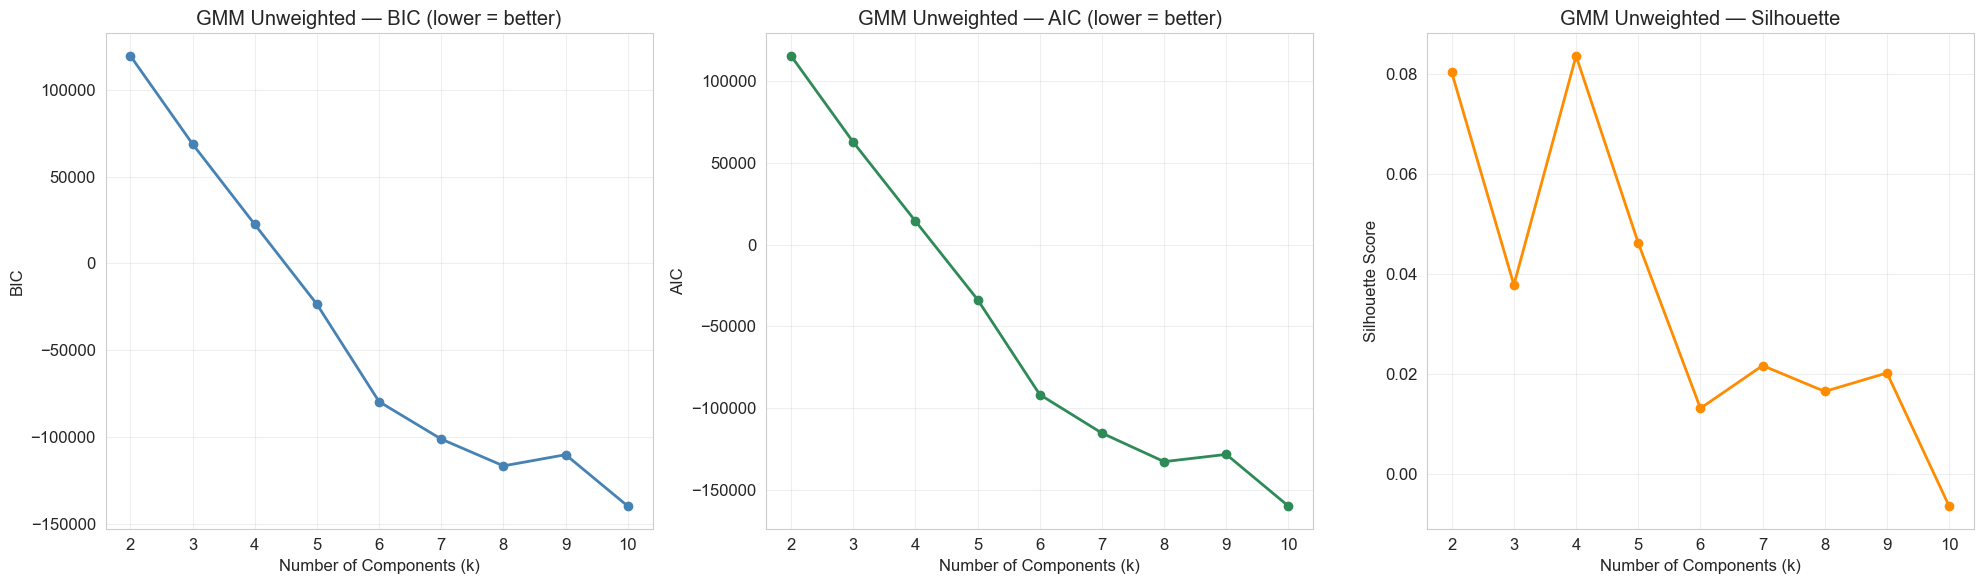

In [48]:
gmm_uw_bics, gmm_uw_aics, gmm_uw_silhouettes, gmm_uw_models = [], [], [], {}

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k, random_state=42,
        covariance_type='full', max_iter=300, n_init=5,
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    sil = silhouette_score(X_scaled, labels)

    gmm_uw_bics.append(bic)
    gmm_uw_aics.append(aic)
    gmm_uw_silhouettes.append(sil)
    gmm_uw_models[k] = gmm
    print(f'  k={k}: BIC={bic:,.0f}  AIC={aic:,.0f}  silhouette={sil:.4f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.plot(list(K_RANGE), gmm_uw_bics, 'o-', linewidth=2, color='steelblue')
ax1.set_xlabel('Number of Components (k)')
ax1.set_ylabel('BIC')
ax1.set_title('GMM Unweighted — BIC (lower = better)')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), gmm_uw_aics, 'o-', linewidth=2, color='seagreen')
ax2.set_xlabel('Number of Components (k)')
ax2.set_ylabel('AIC')
ax2.set_title('GMM Unweighted — AIC (lower = better)')
ax2.grid(True, alpha=0.3)

ax3.plot(list(K_RANGE), gmm_uw_silhouettes, 'o-', linewidth=2, color='darkorange')
ax3.set_xlabel('Number of Components (k)')
ax3.set_ylabel('Silhouette Score')
ax3.set_title('GMM Unweighted — Silhouette')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gmm_uw_bic_aic_silhouette.png', dpi=150)
plt.show()

In [49]:
GMM_UW_K = 3

GMM Unweighted (k=3): silhouette=0.0378

Assignment confidence:
  Mean max probability:   0.989
  Median max probability: 1.000
  Pct with >90% confidence: 96.6%
  Pct with <60% confidence: 0.6%


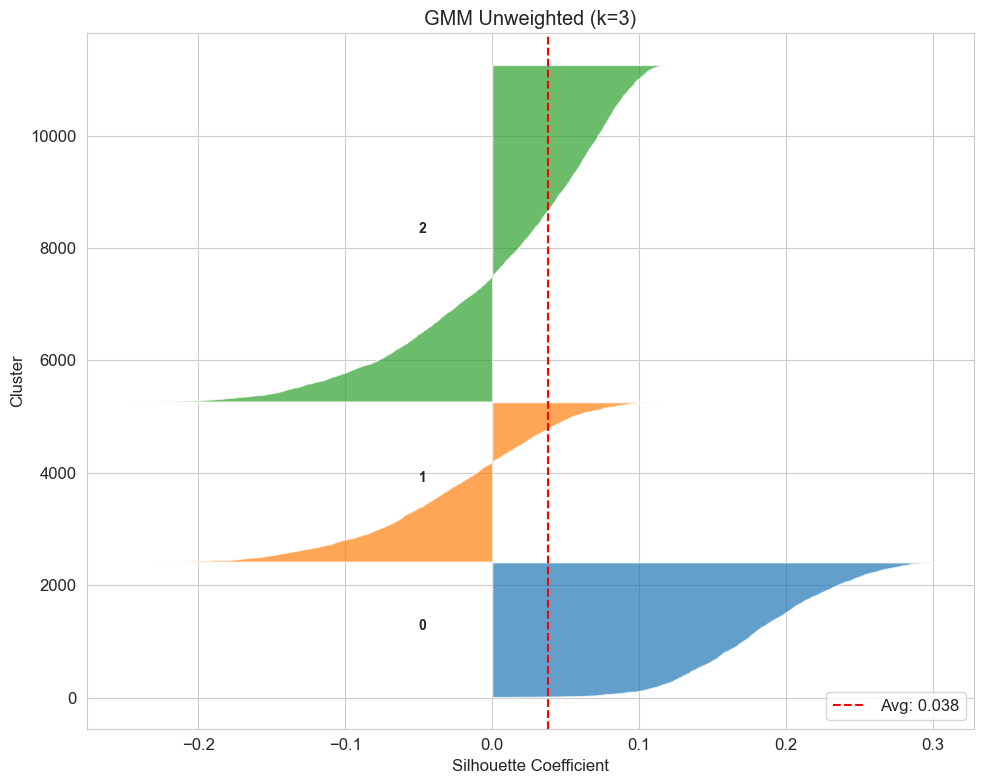


CLUSTER 0 — 2,399 products (21.4%)

  --- Product Info ---
  Top categories:  {'Face Moisturizer': 107, 'Face Serums': 105, 'Travel Size Hair Care': 104, 'Perfume': 103, 'Blush': 67}
  Top brands:      {'Moroccanoil': 40, 'NUDESTIX': 36, 'Living Proof': 34, 'BYOMA': 32, 'Matrix': 32}
  Price range:     $1.69 - $275.00
  Price median:    $28.00
  Price mean:      $38.33
  Price vs cat median: 1.114
  Price bucket dist:
    10-20: 632 (26.3%)
    20-30: 515 (21.5%)
    30-40: 471 (19.6%)
    40-50: 189 (7.9%)
    0-10: 173 (7.2%)

  --- Ratings ---
  Avg rating:      4.627
  Rating std:      0.705
  Rating dispersion over time: 0.699
  Pct 5-star:      0.741 (74.1%)
  Pct 4-star:      0.183 (18.3%)
  Pct 3-star:      0.050 (5.0%)
  Pct 2-star:      0.015 (1.5%)
  Pct 1-star:      0.011 (1.1%)

  --- Sentiment ---
  Avg sentiment:   0.809
  Pct positive:    0.956 (95.6%)
  Pct negative:    0.029 (2.9%)
  Pct neutral:     0.015 (1.5%)

  --- Review Velocity & Engagement ---
  Review count

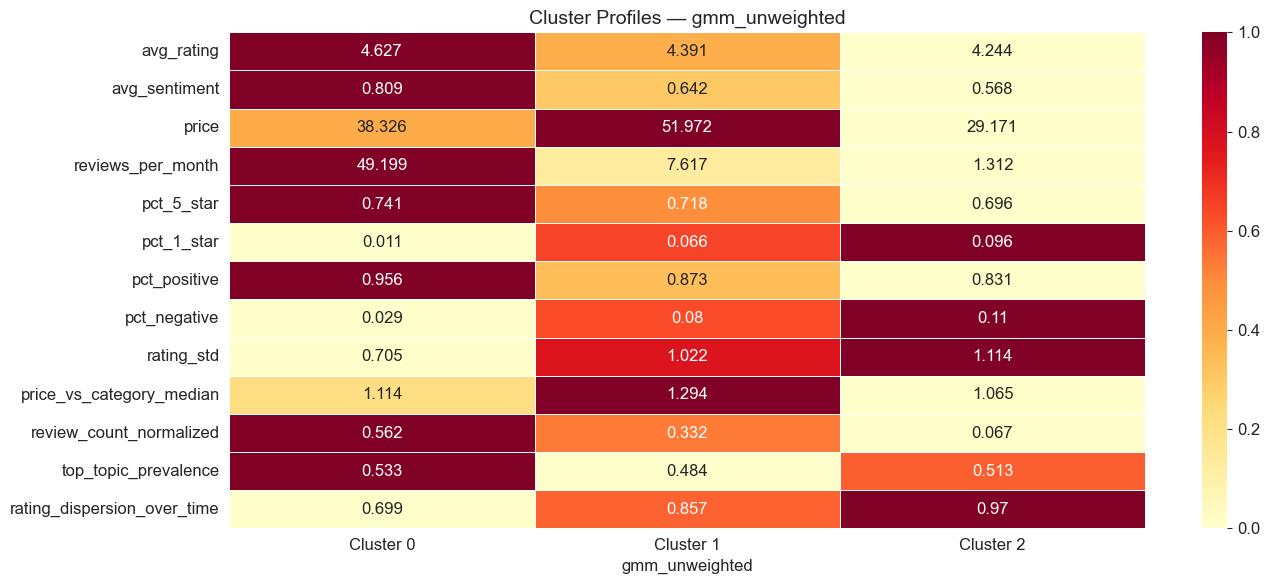


  Cluster 0 (2,399 products, 21.4%)
  Top categories: {'Face Moisturizer': 107, 'Face Serums': 105, 'Travel Size Hair Care': 104, 'Perfume': 103, 'Blush': 67}
  Top brands: {'Moroccanoil': 40, 'NUDESTIX': 36, 'Living Proof': 34, 'BYOMA': 32, 'Matrix': 32}
  Price: $2-$275 (median $28)
  Avg rating: 4.63  |  Avg sentiment: 0.809
  Reviews/month: 49.2  |  Rating std: 0.705

  Cluster 1 (2,839 products, 25.3%)
  Top categories: {'Perfume': 212, 'Face Serums': 116, 'Cologne': 98, 'Face Moisturizer': 98, 'Travel Size Hair Care': 90}
  Top brands: {'jane iredale': 42, "Not Your Mother's": 40, 'e.l.f. Cosmetics': 38, 'Pixi': 34, 'Pacifica': 33}
  Price: $2-$750 (median $28)
  Avg rating: 4.39  |  Avg sentiment: 0.642
  Reviews/month: 7.6  |  Rating std: 1.022

  Cluster 2 (5,989 products, 53.3%)
  Top categories: {'Face Serums': 236, 'Face Moisturizer': 188, 'Travel Size Hair Care': 165, 'Shampoo': 165, 'Face Wash': 134}
  Top brands: {'Naturium': 47, 'Glamnetic': 45, 'RMS Beauty': 45, 'Trul

In [50]:
df['gmm_unweighted'] = gmm_uw_models[GMM_UW_K].predict(X_scaled)
sil = silhouette_score(X_scaled, df['gmm_unweighted'].values)
print(f'GMM Unweighted (k={GMM_UW_K}): silhouette={sil:.4f}\n')

# Soft probabilities
gmm_probs = gmm_uw_models[GMM_UW_K].predict_proba(X_scaled)
for i in range(GMM_UW_K):
    df[f'gmm_uw_prob_cluster_{i}'] = gmm_probs[:, i]

# Show how "soft" assignments are
max_probs = gmm_probs.max(axis=1)
print(f'Assignment confidence:')
print(f'  Mean max probability:   {max_probs.mean():.3f}')
print(f'  Median max probability: {np.median(max_probs):.3f}')
print(f'  Pct with >90% confidence: {(max_probs > 0.9).mean()*100:.1f}%')
print(f'  Pct with <60% confidence: {(max_probs < 0.6).mean()*100:.1f}%')

plot_silhouette_detail(X_scaled, df['gmm_unweighted'].values,
                       f'GMM Unweighted (k={GMM_UW_K})')

for cluster_id in sorted(df['gmm_unweighted'].unique()):
    c = df[df['gmm_unweighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Helpfulness rate:          {c["helpfulness_rate"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Verified Buyer & Recommendation ---')
    print(f'  Pct verified buyer:        {c["pct_verified_buyer"].mean():.3f} ({c["pct_verified_buyer"].mean()*100:.1f}%)')
    print(f'  Pct verified reviewer:     {c["pct_verified_reviewer"].mean():.3f} ({c["pct_verified_reviewer"].mean()*100:.1f}%)')
    print(f'  Pct would recommend:       {c["pct_would_recommend"].mean():.3f} ({c["pct_would_recommend"].mean()*100:.1f}%)')
    print(f'  Pct has disclosure:        {c["pct_has_disclosure"].mean():.3f} ({c["pct_has_disclosure"].mean()*100:.1f}%)')

    # GMM-specific: average soft probabilities per cluster
    prob_cols = [f'gmm_uw_prob_cluster_{i}' for i in range(GMM_UW_K)]
    print(f'\n  --- GMM Soft Probabilities (avg within cluster) ---')
    for pc in prob_cols:
        print(f'    {pc}: {c[pc].mean():.3f}')

# Full brand lists
for cluster_id in sorted(df['gmm_unweighted'].unique()):
    c = df[df['gmm_unweighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

profile_clusters(df, 'gmm_unweighted')

## GMM Unweighted (k=3) — Silhouette: 0.038

The worst-performing model across all methods on Ulta data. The silhouette of 0.038 is barely above zero — meaning on average, products are almost equidistant between their assigned cluster and the nearest alternative. The silhouette plot confirms this: all three clusters have massive negative tails, with Cluster 1 and Cluster 2 extending to -0.2 or beyond. Despite the poor geometric separation, the soft probability diagnostics tell a different story — and that tension is what makes GMM interesting here.

## Assignment Confidence Paradox

The soft probabilities are surprisingly decisive: mean max probability of 0.985–0.993 across clusters, meaning GMM is highly confident in its assignments even though the silhouette says those assignments produce poorly separated clusters. This happens when GMM finds elliptical Gaussian components that overlap substantially in most dimensions but separate cleanly on a few specific dimensions. The model is fitting covariance structure (the shape and orientation of each component) rather than centroid distance (which silhouette measures). It's finding real structure, just not the kind that produces compact spherical clusters.

## Cluster 0 — "Program-Amplified Elite" (2,399 products · 21.4%)

GMM isolates this segment with 98.5% average assignment confidence — the model is certain these products belong together. The profile is the most extreme seeded cluster across any method: 49.2 reviews/month (higher than even hierarchical weighted's 43.9), median review count of 165, and review_count_normalized of 0.562.

The verification signature is the most stark of any cluster in any model: only 0.7% verified buyers — essentially zero organic purchasers reviewing — while 33.5% are verified reviewers with 32.3% disclosure. And the recommendation rate is 94.0%, the highest across every cluster in every model on Ulta. When virtually none of your reviewers purchased the product and nearly all would recommend it, you're looking at a pure sampling-program artifact.

Sentiment of 0.809 is the highest across any Ulta cluster in any model, with 95.6% positive and only 2.9% negative. Rating of 4.63 with 0.705 std is tight and strong. But the 0.7% verified buyer rate means this sentiment reflects the opinions of people who received free product, not people who spent money.

Brands are the established program infrastructure: Moroccanoil, NUDESTIX, Living Proof, BYOMA, Matrix, Dior, bareMinerals, L'Oréal, MAC, BOBBI BROWN. The top topic is Topic 2 (not Topic 8 or 1 which dominate other clusters), suggesting seeded reviews discuss products differently — likely more formulaic positive language around discovery and first impressions rather than repeat-purchase loyalty or complaint patterns.

GMM's unique contribution here is isolating the purest expression of the seeded segment. K-Means included some products with moderate disclosure rates; GMM's covariance modeling identifies the component where near-zero verified buyer intersects with high disclosure and extreme velocity. This is the cleanest evidence for your paper's incentivized review argument.

## Cluster 1 — "Premium Established Middle" (2,839 products · 25.3%)

This is the cluster GMM discovers that no other method surfaces as clearly. It's not the underperformers (rating 4.39 is decent), not the loyalists (1.022 std is too high), and not the seeded high-traffic (7.6 reviews/month is moderate). It's the premium middle — products with established presence, decent but imperfect reception, and notably the highest prices.

Price is the standout: mean $51.97, median $28, price_vs_category_median of 1.294 — nearly 30% above category median. This is the most expensive cluster in any model. Categories are fragrance-heavy (Perfume 212, Cologne 98), which drives the price distribution upward. Brands are a mix of prestige heritage (jane iredale, CHANEL, Clinique, Estée Lauder, Gucci) and accessible quality (e.l.f., Pixi, Not Your Mother's, Pacifica).

The verification profile is mixed: 26.9% verified buyer, 46.4% verified reviewer, 27.6% disclosure. This is a hybrid — some organic reviews, some program-driven — which is exactly what GMM's Gaussian mixture modeling should capture. These products aren't purely seeded like Cluster 0, but they're not organically reviewed like Cluster 2 either. They sit at the intersection, and GMM's soft probability framework naturally models this blend.

Sentiment of 0.642 with 87.3% positive is solid but not exceptional. The 6.6% 1-star and 8.0% negative rate suggest these products have real detractors — not enough to be polarizing, but enough to indicate some customers paying premium prices feel disappointed. Topic 8 dominates at 28.8%, the complaint-associated topic, consistent with price-expectation mismatches.

The 63.3% recommendation rate is informative in context: lower than Cluster 0's inflated 94.0%, higher than Cluster 2's 42.5%. This middle position tracks with the hybrid verification profile — some recommendations come from sampling participants (biased upward), some from real purchasers (more honest).

## Cluster 2 — "Low-Velocity Organic Long Tail" (5,989 products · 53.3%)

The majority cluster, and the one GMM is most confident about (99.3% average assignment probability). Over half the assortment, with the lowest velocity (1.3 reviews/month), lowest price (mean $29.17, median $24), and critically: 0.0% disclosure. Not low disclosure — zero. No product in this cluster has disclosure-bearing reviews. Combined with 18.9% verified buyer and 12.5% verified reviewer, this is the purely organic segment.

But unlike K-Means' "Quiet Loyalists" (which had high ratings and tight consistency), GMM's organic cluster includes the underperformers. Rating of 4.24 with 1.114 std, 9.6% 1-star, 11.0% negative — this cluster contains both the beloved indie products AND the struggling budget products. GMM merged them because they share the same review provenance (organic, low-volume, zero-disclosure) even though their quality profiles differ.

This is GMM's fundamental limitation on this data: it optimizes for Gaussian component fit, and the "organic, low-velocity" products form a single wide Gaussian in feature space rather than two tight ones. K-Means, which measures distance to centroids, can separate this blob into loyalists and underperformers. GMM, which fits elliptical distributions, sees one broad component.

Brands confirm the merge: Naturium and RMS Beauty (beloved) sit alongside Glamnetic and J.Cat Beauty (polarizing). The 42.5% recommendation rate — the lowest across clusters — is dragged down by the underperformers mixed in.

Topic 8 dominates at 30.0% (complaint-associated), higher than any other cluster, precisely because the underperformers are folded in here. Rating dispersion over time is 0.970 — the highest, again because it's averaging the low-dispersion loyalists with the high-dispersion underperformers.

---

## GMM's Unique Contribution and Limitations

GMM Unweighted's 0.038 silhouette makes it the weakest model geometrically, but it offers two insights no other method provides.

First, the purity of Cluster 0's seeded isolation. The 0.7% verified buyer rate is the most extreme finding across all models. By fitting covariance structure, GMM found the tightest possible boundary around the pure sampling-program products — tighter than K-Means (which included some products with moderate organic review rates) or hierarchical (which needed weighting to even attempt the separation). For a paper arguing that incentivized reviews systematically inflate brand perception on Ulta, Cluster 0 is your strongest evidence.

Second, the premium middle cluster. GMM's Cluster 1 captures products that other methods distribute across their loyalist and mainstream segments. These are expensive, moderately reviewed products with hybrid verification profiles — exactly the products where the line between organic and incentivized sentiment is blurriest. This cluster identifies the assortment zone where further investigation of review authenticity would be most valuable.

The limitation is the merged organic cluster. By combining loyalists and underperformers into one 53.3% blob, GMM sacrifices the most actionable marketing segmentation — knowing which organic products to amplify vs which to intervene on. This is why GMM alone can't serve as the recommended model, but its seeded cluster finding should be referenced alongside K-Means Weighted as converging evidence.

# Model 6: Gaussian Mixture Model (Weighted)

  k=2: BIC=268,473  AIC=264,436  silhouette=0.1027
  k=3: BIC=209,867  AIC=203,808  silhouette=0.0675
  k=4: BIC=158,591  AIC=150,510  silhouette=0.0371
  k=5: BIC=186,910  AIC=176,807  silhouette=0.0707
  k=6: BIC=71,427  AIC=59,303  silhouette=0.0107
  k=7: BIC=57,941  AIC=43,794  silhouette=0.0382
  k=8: BIC=36,148  AIC=19,979  silhouette=0.0441
  k=9: BIC=11,848  AIC=-6,342  silhouette=-0.0107
  k=10: BIC=7,095  AIC=-13,118  silhouette=0.0056


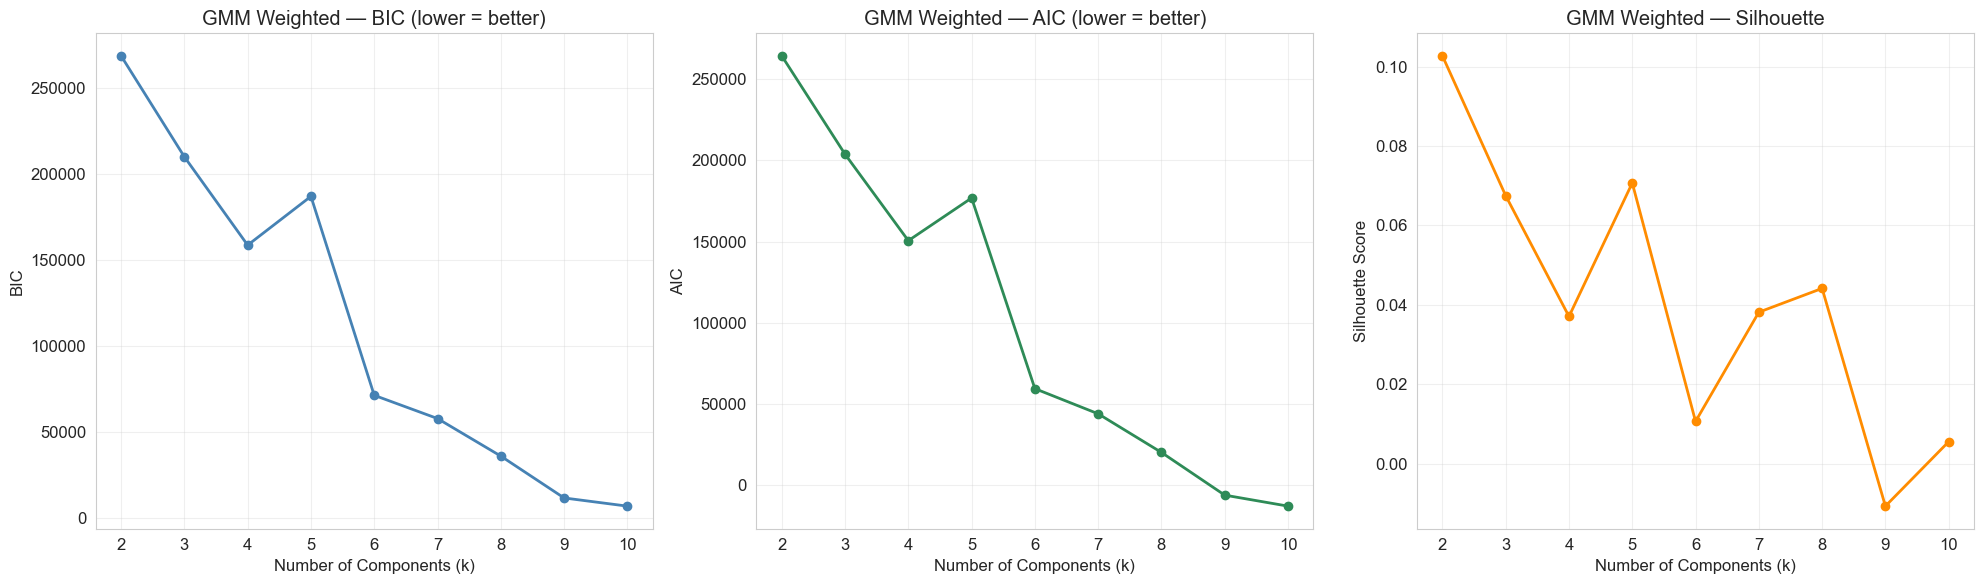

In [51]:
gmm_w_bics, gmm_w_aics, gmm_w_silhouettes, gmm_w_models = [], [], [], {}

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k, random_state=42,
        covariance_type='full', max_iter=300, n_init=5,
    )
    gmm.fit(X_weighted)
    labels = gmm.predict(X_weighted)
    bic = gmm.bic(X_weighted)
    aic = gmm.aic(X_weighted)
    sil = silhouette_score(X_weighted, labels)

    gmm_w_bics.append(bic)
    gmm_w_aics.append(aic)
    gmm_w_silhouettes.append(sil)
    gmm_w_models[k] = gmm
    print(f'  k={k}: BIC={bic:,.0f}  AIC={aic:,.0f}  silhouette={sil:.4f}')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.plot(list(K_RANGE), gmm_w_bics, 'o-', linewidth=2, color='steelblue')
ax1.set_xlabel('Number of Components (k)')
ax1.set_ylabel('BIC')
ax1.set_title('GMM Weighted — BIC (lower = better)')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), gmm_w_aics, 'o-', linewidth=2, color='seagreen')
ax2.set_xlabel('Number of Components (k)')
ax2.set_ylabel('AIC')
ax2.set_title('GMM Weighted — AIC (lower = better)')
ax2.grid(True, alpha=0.3)

ax3.plot(list(K_RANGE), gmm_w_silhouettes, 'o-', linewidth=2, color='darkorange')
ax3.set_xlabel('Number of Components (k)')
ax3.set_ylabel('Silhouette Score')
ax3.set_title('GMM Weighted — Silhouette')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gmm_w_bic_aic_silhouette.png', dpi=150)
plt.show()

In [52]:
GMM_W_K = 4

GMM Weighted (k=4): silhouette=0.0371

Assignment confidence:
  Mean max probability:   0.989
  Median max probability: 1.000
  Pct with >90% confidence: 96.4%
  Pct with <60% confidence: 0.7%


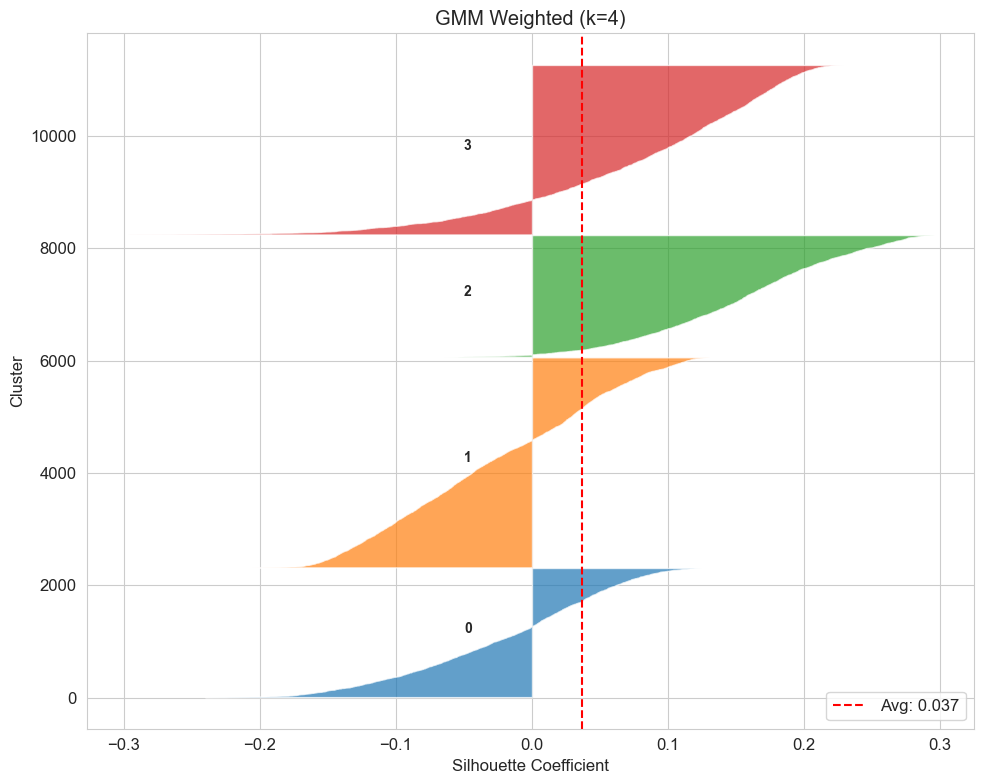


CLUSTER 0 — 2,300 products (20.5%)

  --- Product Info ---
  Top categories:  {'Perfume': 136, 'Face Serums': 91, 'Face Moisturizer': 82, 'Cologne': 76, 'Travel Size Hair Care': 68}
  Top brands:      {"Not Your Mother's": 39, 'jane iredale': 37, 'e.l.f. Cosmetics': 35, 'Pixi': 34, 'Kiss': 31}
  Price range:     $2.50 - $749.99
  Price median:    $26.00
  Price mean:      $44.08
  Price vs cat median: 1.123
  Price bucket dist:
    10-20: 647 (28.1%)
    20-30: 437 (19.0%)
    30-40: 343 (14.9%)
    0-10: 240 (10.4%)
    40-50: 160 (7.0%)

  --- Ratings ---
  Avg rating:      4.408
  Rating std:      1.004
  Rating dispersion over time: 0.865
  Pct 5-star:      0.714 (71.4%)
  Pct 4-star:      0.135 (13.5%)
  Pct 3-star:      0.056 (5.6%)
  Pct 2-star:      0.036 (3.6%)
  Pct 1-star:      0.059 (5.9%)

  --- Sentiment ---
  Avg sentiment:   0.651
  Pct positive:    0.879 (87.9%)
  Pct negative:    0.077 (7.7%)
  Pct neutral:     0.045 (4.5%)

  --- Review Velocity & Engagement ---
  R

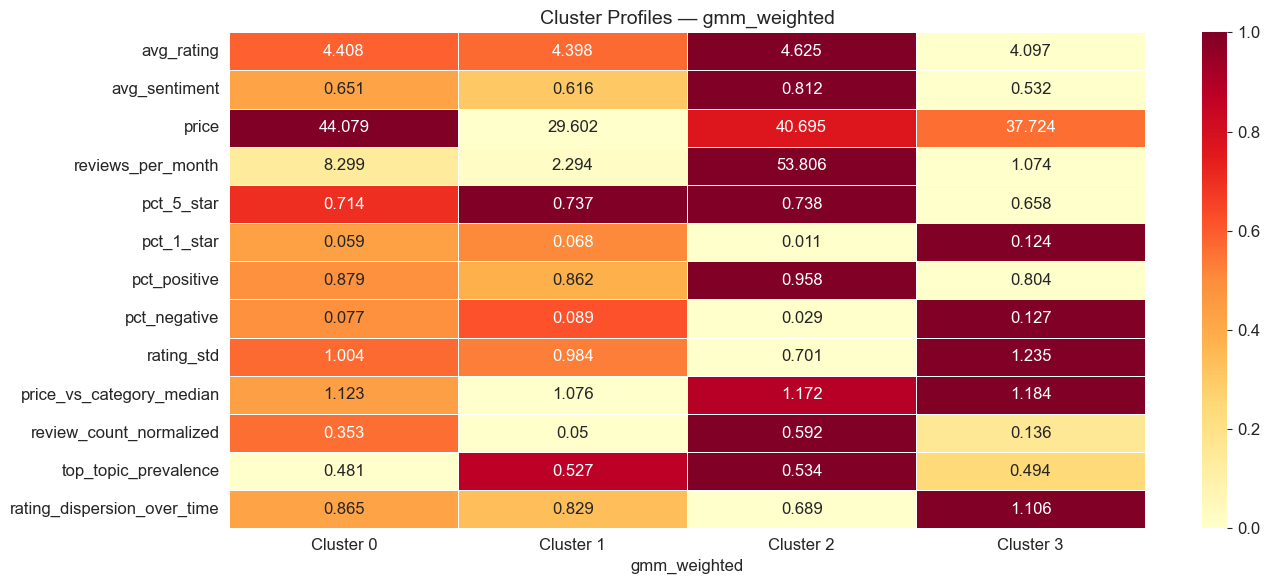


  Cluster 0 (2,300 products, 20.5%)
  Top categories: {'Perfume': 136, 'Face Serums': 91, 'Face Moisturizer': 82, 'Cologne': 76, 'Travel Size Hair Care': 68}
  Top brands: {"Not Your Mother's": 39, 'jane iredale': 37, 'e.l.f. Cosmetics': 35, 'Pixi': 34, 'Kiss': 31}
  Price: $2-$750 (median $26)
  Avg rating: 4.41  |  Avg sentiment: 0.651
  Reviews/month: 8.3  |  Rating std: 1.004

  Cluster 1 (3,741 products, 33.3%)
  Top categories: {'Face Serums': 154, 'Face Moisturizer': 118, 'Travel Size Hair Care': 101, 'Face Wash': 80, 'Lip Balms': 79}
  Top brands: {'RMS Beauty': 46, 'The INKEY List': 39, 'Glamnetic': 38, 'Saje Natural Wellness': 38, 'amika': 37}
  Price: $2-$190 (median $25)
  Avg rating: 4.40  |  Avg sentiment: 0.616
  Reviews/month: 2.3  |  Rating std: 0.984

  Cluster 2 (2,167 products, 19.3%)
  Top categories: {'Face Moisturizer': 102, 'Perfume': 97, 'Face Serums': 97, 'Travel Size Hair Care': 88, 'Blush': 64}
  Top brands: {'NUDESTIX': 35, 'Matrix': 32, 'BYOMA': 30, 'Livi

In [53]:
df['gmm_weighted'] = gmm_w_models[GMM_W_K].predict(X_weighted)
sil = silhouette_score(X_weighted, df['gmm_weighted'].values)
print(f'GMM Weighted (k={GMM_W_K}): silhouette={sil:.4f}\n')

# Soft probabilities
gmm_w_probs = gmm_w_models[GMM_W_K].predict_proba(X_weighted)
for i in range(GMM_W_K):
    df[f'gmm_w_prob_cluster_{i}'] = gmm_w_probs[:, i]

# Assignment confidence
max_probs = gmm_w_probs.max(axis=1)
print(f'Assignment confidence:')
print(f'  Mean max probability:   {max_probs.mean():.3f}')
print(f'  Median max probability: {np.median(max_probs):.3f}')
print(f'  Pct with >90% confidence: {(max_probs > 0.9).mean()*100:.1f}%')
print(f'  Pct with <60% confidence: {(max_probs < 0.6).mean()*100:.1f}%')

plot_silhouette_detail(X_weighted, df['gmm_weighted'].values,
                       f'GMM Weighted (k={GMM_W_K})')

for cluster_id in sorted(df['gmm_weighted'].unique()):
    c = df[df['gmm_weighted'] == cluster_id]
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products ({len(c)/len(df)*100:.1f}%)')
    print(f'{"=" * 70}')

    print(f'\n  --- Product Info ---')
    print(f'  Top categories:  {c["category"].value_counts().head(5).to_dict()}')
    print(f'  Top brands:      {c["brand"].value_counts().head(5).to_dict()}')
    print(f'  Price range:     ${c["price"].min():.2f} - ${c["price"].max():.2f}')
    print(f'  Price median:    ${c["price"].median():.2f}')
    print(f'  Price mean:      ${c["price"].mean():.2f}')
    print(f'  Price vs cat median: {c["price_vs_category_median"].mean():.3f}')
    print(f'  Price bucket dist:')
    for bucket, count in c['price_bucket'].value_counts().head(5).items():
        print(f'    {bucket}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Ratings ---')
    print(f'  Avg rating:      {c["avg_rating"].mean():.3f}')
    print(f'  Rating std:      {c["rating_std"].mean():.3f}')
    print(f'  Rating dispersion over time: {c["rating_dispersion_over_time"].mean():.3f}')
    print(f'  Pct 5-star:      {c["pct_5_star"].mean():.3f} ({c["pct_5_star"].mean()*100:.1f}%)')
    print(f'  Pct 4-star:      {c["pct_4_star"].mean():.3f} ({c["pct_4_star"].mean()*100:.1f}%)')
    print(f'  Pct 3-star:      {c["pct_3_star"].mean():.3f} ({c["pct_3_star"].mean()*100:.1f}%)')
    print(f'  Pct 2-star:      {c["pct_2_star"].mean():.3f} ({c["pct_2_star"].mean()*100:.1f}%)')
    print(f'  Pct 1-star:      {c["pct_1_star"].mean():.3f} ({c["pct_1_star"].mean()*100:.1f}%)')

    print(f'\n  --- Sentiment ---')
    print(f'  Avg sentiment:   {c["avg_sentiment"].mean():.3f}')
    print(f'  Pct positive:    {c["pct_positive"].mean():.3f} ({c["pct_positive"].mean()*100:.1f}%)')
    print(f'  Pct negative:    {c["pct_negative"].mean():.3f} ({c["pct_negative"].mean()*100:.1f}%)')
    print(f'  Pct neutral:     {c["pct_neutral"].mean():.3f} ({c["pct_neutral"].mean()*100:.1f}%)')

    print(f'\n  --- Review Velocity & Engagement ---')
    print(f'  Review count (mean):       {c["review_count"].mean():.1f}')
    print(f'  Review count (median):     {c["review_count"].median():.0f}')
    print(f'  Review count normalized:   {c["review_count_normalized"].mean():.3f}')
    print(f'  Reviews per month:         {c["reviews_per_month"].mean():.2f}')
    print(f'  Helpfulness rate:          {c["helpfulness_rate"].mean():.3f}')

    print(f'\n  --- Topics ---')
    print(f'  Dominant topic mode:       {c["dominant_topic_mode"].mode().iloc[0]}')
    print(f'  Top topic prevalence:      {c["top_topic_prevalence"].mean():.3f} ({c["top_topic_prevalence"].mean()*100:.1f}%)')
    print(f'  Topic distribution:')
    for topic, count in c['dominant_topic_mode'].value_counts().head(5).items():
        print(f'    Topic {int(topic)}: {count} ({count/len(c)*100:.1f}%)')

    print(f'\n  --- Verified Buyer & Recommendation ---')
    print(f'  Pct verified buyer:        {c["pct_verified_buyer"].mean():.3f} ({c["pct_verified_buyer"].mean()*100:.1f}%)')
    print(f'  Pct verified reviewer:     {c["pct_verified_reviewer"].mean():.3f} ({c["pct_verified_reviewer"].mean()*100:.1f}%)')
    print(f'  Pct would recommend:       {c["pct_would_recommend"].mean():.3f} ({c["pct_would_recommend"].mean()*100:.1f}%)')
    print(f'  Pct has disclosure:        {c["pct_has_disclosure"].mean():.3f} ({c["pct_has_disclosure"].mean()*100:.1f}%)')

    # GMM-specific: average soft probabilities per cluster
    prob_cols = [f'gmm_uw_prob_cluster_{i}' for i in range(GMM_UW_K)]
    print(f'\n  --- GMM Soft Probabilities (avg within cluster) ---')
    for pc in prob_cols:
        print(f'    {pc}: {c[pc].mean():.3f}')

# Full brand lists
for cluster_id in sorted(df['gmm_weighted'].unique()):
    c = df[df['gmm_weighted'] == cluster_id]
    brand_counts = c['brand'].value_counts()
    print(f'\n{"=" * 70}')
    print(f'CLUSTER {cluster_id} — {len(c):,} products, {brand_counts.nunique()} unique brands')
    print(f'{"=" * 70}')
    for brand, count in brand_counts.items():
        print(f'  {brand:<45} {count:>3} ({count/len(c)*100:.1f}%)')

profile_clusters(df, 'gmm_weighted')

## GMM Weighted (k=4) — Silhouette: 0.037

Weighting didn't rescue GMM geometrically — 0.037 is virtually identical to GMM Unweighted's 0.038. This is the only method where weighting produced no silhouette improvement. But the story isn't in the silhouette; it's in what the fourth cluster reveals about the verification dimension that no other model on Ulta has separated this cleanly.

The soft probability crosswalk to GMM Unweighted tells us exactly what happened. Cluster 2 here maps to GMM UW Cluster 0 (98.5% probability match) — the seeded elite is unchanged. Cluster 0 maps to GMM UW Cluster 1 (94.5%) — the premium middle persists. The critical development: GMM Unweighted's massive Cluster 2 (the 53.3% organic blob that merged loyalists and underperformers) has been split. Cluster 1 here draws 92.5% from UW Cluster 2, while Cluster 3 draws 81.9% from UW Cluster 2 with a 17.2% pull toward UW Cluster 1. Weighting gave GMM just enough signal to crack the organic mass into two components.

But the split isn't the one K-Means makes (quality-based: loyalists vs underperformers). It's a verification-provenance split that only GMM's covariance modeling discovers.

## Cluster 2 — "Program-Amplified Elite" (2,167 products · 19.3%)

Nearly identical to GMM Unweighted's Cluster 0, slightly tighter (2,167 vs 2,399 products). The verification signature is the most extreme in any model: 0.6% verified buyer, 34.8% verified reviewer, 33.8% disclosure, 94.0% recommendation. Velocity is the highest across any cluster in any model at 53.8 reviews/month, with median review count of 182.

Sentiment of 0.812 with 95.8% positive and only 1.1% 1-star. Rating 4.63, std 0.701, dispersion over time 0.689 — the tightest consistency anywhere. Topic 2 dominates (22.4%), not Topic 8, reinforcing that seeded reviews generate a distinct discourse pattern.

Brands: NUDESTIX, Matrix, BYOMA, Living Proof, bareMinerals, Dior, MAC, Murad, L'Oréal, BOBBI BROWN. The usual sampling infrastructure players, even more concentrated than in GMM Unweighted because weighting pushed borderline products out.

The soft probabilities confirm this is the most distinctive component: 98.5% assignment confidence to its UW counterpart. GMM is most certain about this cluster because the covariance structure — near-zero buyer verification intersecting extreme velocity and high disclosure — creates a tight, well-defined Gaussian component with minimal overlap.

## Cluster 0 — "Disclosure-Active Middle" (2,300 products · 20.5%)

Maps to GMM Unweighted's Cluster 1 (the premium middle), and the verification profile confirms: 25.2% verified buyer, 51.8% verified reviewer, 35.9% disclosure. This is the hybrid zone — substantial organic purchasing AND substantial program participation coexisting within the same products.

The key distinction from Cluster 2: these products have real buyers alongside their program reviewers. One in four reviews comes from someone who actually purchased the product. That's enough organic signal to anchor the sentiment (0.651) and recommendation rate (63.0%) closer to reality than Cluster 2's inflated 94.0%.

Rating of 4.41 with 1.004 std is moderate — higher variance than the seeded cluster because organic reviews introduce honest dissatisfaction that sampling participants rarely express. The 5.9% 1-star rate is 5× higher than Cluster 2's 1.1%, directly attributable to the verified buyer contingent.

Price is the highest across any weighted cluster at $44.08 mean — fragrance-heavy (Perfume 136, Cologne 76) drives this upward. Brands are the prestige-accessible mix: Not Your Mother's, jane iredale, e.l.f., Pixi, Kiss, KYLIE COSMETICS, Philosophy, fresh. These brands participate in sampling programs (35.9% disclosure) but also generate genuine purchase traffic.

Topic 8 dominates at 28.7% — the complaint-associated topic — which tracks with the real buyer contingent expressing real frustrations at premium price points.

## Cluster 1 — "Zero-Verification Organic" (3,741 products · 33.3%)

This is the larger fragment of GMM Unweighted's merged blob, and its verification profile is the most striking discovery of the four-cluster solution: 0.0% verified reviewer, 0.0% disclosure, and only 10.6% verified buyer. These products exist in a verification vacuum — virtually no reviews carry any form of authentication.

The 34.9% recommendation rate is the lowest across any cluster in any model on Ulta. But this isn't because the products are bad — rating of 4.40 and sentiment of 0.616 are moderate. The low recommendation comes from the absence of sampling participants, who reflexively recommend products they received for free. Without that artificial inflation, the organic recommendation rate settles to its natural level.

Velocity is 2.3 reviews/month with median review count of only 18 — these are low-attention products. Price caps at $190 (the lowest maximum across clusters), median $25. Brands are a mix of beloved indie (RMS Beauty, amika, Rare Beauty, TATCHA, Sol de Janeiro) and emerging/niche (The INKEY List, Saje Natural Wellness, LUSH, LE MONDE GOURMAND, Coco & Eve, medicube).

The critical insight: many products here that K-Means classified as "Quiet Loyalists" — RMS Beauty, amika, COSRX, Kopari Beauty — land in this zero-verification cluster. They're genuinely loved (4.40 rating, 73.7% 5-star) but completely outside Ulta's review verification and sampling infrastructure. Their sentiment is authentic but unverifiable by platform mechanisms.

Rating std of 0.984 is moderate, and 6.8% 1-star shows these products aren't uniformly excellent — the cluster contains some underperformers too. But the defining characteristic isn't quality; it's verification absence. GMM is grouping by the shape of the review ecosystem, not by product performance.

## Cluster 3 — "Verified Disappointment" (3,019 products · 26.9%)

The fourth cluster — the one weighting created — and the most actionable for marketing intervention. Verification profile: 30.5% verified buyer, 30.6% verified reviewer, but 0.0% disclosure. These products have authentic verification (people who actually bought and received them) with zero sampling program involvement. The reviews are genuine, verified, and negative.

This is the segment where the truth hurts. Rating of 4.10 is the lowest across clusters — still acceptable, but 12.4% 1-star is the highest across any cluster in any model on Ulta except hierarchical unweighted's extreme underperformer segment. Sentiment of 0.532 is the lowest across all four clusters, with 12.7% negative — also the highest. Rating std of 1.235 is extreme, meaning these products provoke violently split opinions. Rating dispersion over time is 1.106 — the highest — indicating quality inconsistency across product batches or formulation changes.

Helpfulness rate of 0.817 is the highest across all four clusters. When verified buyers write negative reviews, other shoppers find them useful. This is Ulta's "helpful complaint" segment — real customers sharing real problems, and the community engaging with those critiques.

Brands: Paul Mitchell, CHANEL, Essence, PATTERN, Naturium, Joico, ColourPop, Juvia's Place, Drunk Elephant, The Ordinary, BLK/OPL, Briogeo, ELEMIS, L.A. Girl, Tarte, Verb, CHI, L'anza. This is the widest brand quality range — from luxury (CHANEL, Drunk Elephant, ELEMIS) to drugstore (Essence, L.A. Girl, ColourPop). What unites them isn't price positioning but verified purchaser dissatisfaction.

Topic 8 dominates at 33.6% (the highest Topic 8 concentration across any cluster in any model), and Topic 1 is at 28.6%. This two-topic concentration (62.2% combined) means reviews are overwhelmingly complaint-oriented, and the complaint discourse is focused rather than diffuse.

The 59.9% recommendation rate looks moderate, but remember: with 0.0% disclosure, this isn't inflated by sampling. When 40% of verified purchasers would not recommend a product, that's a genuine satisfaction crisis requiring intervention.

---

## What the Fourth Cluster Reveals

The GMM Weighted four-cluster solution produces a verification taxonomy that no other method discovers:

| Cluster | Verified Buyer | Verified Reviewer | Disclosure | Interpretation |
|---|---|---|---|---|
| 2 (Seeded) | 0.6% | 34.8% | 33.8% | Free product, no purchase |
| 0 (Hybrid) | 25.2% | 51.8% | 35.9% | Mixed organic + program |
| 1 (Unverified) | 10.6% | 0.0% | 0.0% | No verification at all |
| 3 (Verified Organic) | 30.5% | 30.6% | 0.0% | Real purchases, no programs |

This is a four-tier verification provenance framework. The seeded cluster (Cluster 2) has reviewers but not buyers. The hybrid (Cluster 0) has both buyers and program participants. The unverified (Cluster 1) has neither. The verified organic (Cluster 3) has buyers and reviewers but no incentivization.

The marketing implication is sharp: Cluster 3's low sentiment is the most trustworthy signal in the entire Ulta dataset because it comes from verified purchasers with no incentive to be positive. These are the products most urgently needing formulation review, customer experience improvement, or strategic repositioning. By contrast, Cluster 2's high sentiment is the least trustworthy — built almost entirely on free product.

## GMM Weighted's Limitation

Despite the insight, the 0.037 silhouette means GMM still can't produce geometrically clean clusters on this data. The silhouette plot confirms it — Cluster 1 (orange) and Cluster 3 (red) have massive negative tails extending to -0.3, and even Cluster 2 (green, the cleanest) has substantial negative coefficients. GMM's elliptical Gaussian assumption doesn't match Ulta's feature space geometry, regardless of weighting.

The model's value is exclusively interpretive: it discovers the verification provenance taxonomy as converging evidence alongside K-Means and hierarchical findings, not as a standalone segmentation solution. For your paper, GMM Weighted's Cluster 3 provides the cleanest definition of "verified organic disappointment" — the segment where incentivized review inflation is provably absent and low sentiment reflects genuine market signal.

# Final Findings

In [54]:
df[["product_id", "kmeans_weighted"]].to_csv(
    PROCESSED_DIR / "ulta_cluster_labels.csv", index=False
)
print(f"Saved {len(df):,} rows → ulta_cluster_labels.csv")
print(df["kmeans_weighted"].value_counts().sort_index())

Saved 11,227 rows → ulta_cluster_labels.csv
kmeans_weighted
0    3545
1    2876
2    4806
Name: count, dtype: int64


## Model Selection: Ulta Market Segmentation

### Performance Summary

| Model | k | Silhouette | Weighting Δ | Key Strength | Key Limitation |
|---|---|---|---|---|---|
| K-Means Unweighted | 3 | 0.130 | — | Clean three-segment baseline | Seeded cluster includes moderate-disclosure products |
| **K-Means Weighted** | **3** | **0.167** | **+28%** | **Sharpest segment boundaries, highest silhouette** | **Doesn't surface verification provenance taxonomy** |
| Hierarchical Unweighted | 3 | 0.077 | — | Extreme underperformer thresholding | Merges seeded + organic into one blob |
| Hierarchical Weighted | 3 | 0.133 | +73% | Purest seeded cluster (20.4%) | Quiet Loyalists absorb too many moderate products |
| GMM Unweighted | 3 | 0.038 | — | 0.7% verified buyer isolation | Merges loyalists + underperformers into 53% blob |
| GMM Weighted | 4 | 0.037 | -3% | Four-tier verification taxonomy | Worst geometric separation across all models |

### Recommendation: K-Means Weighted (k=3)

K-Means Weighted is the recommended model for Ulta, for the same structural reasons it won on Sephora — but with a finding that has no Sephora parallel.

**Silhouette leadership.** At 0.167, it produces the best-separated clusters across all six models. The +28% improvement from weighting confirms that the 2× sentiment/velocity and 1.5× verification weights correctly emphasize the dimensions that matter most for Ulta's assortment structure.

**Three-segment actionability.** The solution maps directly to merchandising decisions:

- **Polarizing Underperformers** (31.6%) — intervention candidates. Rating 3.83, std 1.51, 1.6 reviews/month. Action: formulation review, delist evaluation, promotional repricing.
- **Seeded High-Traffic** (25.6%) — audit candidates. 38.6 reviews/month, 57.3% verified reviewer vs only 9.0% verified buyer, 47.4% disclosure. Action: verify whether brand perception survives when filtered to organic-only reviews; renegotiate sampling partnerships for brands where it doesn't.
- **Quiet Loyalists** (42.8%) — amplification candidates. Rating 4.56, std 0.706, 93.3% positive, organically reviewed. Action: increase visibility, expand trial programs, leverage authentic advocacy.

**The Ulta-specific finding.** The seeded cluster's verification signature — 9% buyers vs 57% reviewers, nearly half of all reviews carrying disclosure — has no Sephora equivalent because Sephora doesn't expose verification metadata. This is K-Means Weighted's most important contribution: quantifying the scale of incentivized review activity on Ulta and identifying exactly which brands and categories are most program-dependent. The cluster is large enough (25.6% of assortment) to be structurally significant, not a statistical edge case.

### Cross-Method Convergence

The three-segment structure — seeded high-traffic, polarizing underperformers, quiet loyalists — is robust across algorithmic choice. Every model that successfully separates the verification dimension recovers this taxonomy:

- K-Means Weighted finds it with the cleanest boundaries
- Hierarchical Weighted finds it after a +73% silhouette correction, with a smaller and purer seeded cluster (20.4%)
- GMM Unweighted finds the purest seeded isolation (0.7% verified buyer) but can't separate the organic segments

This convergence means the finding isn't an artifact of K-Means' centroid initialization or distance metric. Three independent algorithmic paradigms — centroid-based, agglomerative, and probabilistic — all identify the same fundamental structure when given adequate signal on the verification dimensions.

### GMM's Supporting Role

GMM Weighted shouldn't be the primary model (0.037 silhouette is near-zero), but its four-tier verification taxonomy deserves citation as converging evidence. The distinction between "zero-verification organic" (Cluster 1: 0% disclosure, 0% verified reviewer) and "verified organic disappointment" (Cluster 3: 30.5% verified buyer, 0% disclosure, 12.4% 1-star) surfaces a nuance that K-Means' three-cluster solution compresses. For a deeper investigation of review authenticity on Ulta, GMM's framework suggests there are actually four verification provenance modes, not three — but the data geometry doesn't support separating them cleanly enough for primary segmentation.

### Weighting's Differential Impact

The weighting story on Ulta is methodologically interesting. It dramatically improved both centroid-based methods (K-Means +28%, hierarchical +73%) but did nothing for GMM (-3%). This makes sense: K-Means and hierarchical clustering compute distances between points or cluster centers, so scaling features by importance directly changes which points are "close." GMM fits multivariate Gaussians by maximizing likelihood — the covariance matrices already adapt to feature scales, so external weighting is largely redundant with what the EM algorithm does internally. The lesson for the paper: feature weighting is most valuable for distance-based methods on datasets with orthogonal dimensions of differing importance, which is exactly what Ulta's quality-gradient + verification structure presents.